# Step 1. Preliminaries

## 1.1 Import Libraries

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from collections import defaultdict
import torch
import torch.nn as nn

import helpers 

# Configuration
DATA_DIR = 'CamelinaMAGIC-Dataset-Complete'
EXPERIMENTS = [1, 2, 3] # We will process all three
RANDOMIZATION_FILE = os.path.join(DATA_DIR, 'CamelinaMAGIC-ALL-Randomization.xlsx')

print("Libraries imported and configuration set.")

Libraries imported and configuration set.


## 1.2 Loading Data and Processing

Loading data from Experiments: [1, 2, 3]
  Processing Experiment 1...


h:\878Project\CMPT-878-Project2\helpers.py:462: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df_weather.resample(resample_freq, label="left", closed="left").mean()


  Processing Experiment 2...


h:\878Project\CMPT-878-Project2\helpers.py:462: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df_weather.resample(resample_freq, label="left", closed="left").mean()


  Processing Experiment 3...


h:\878Project\CMPT-878-Project2\helpers.py:462: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df_weather.resample(resample_freq, label="left", closed="left").mean()


Number of dataframes in the dict exp_transpiration_dataframes: 3


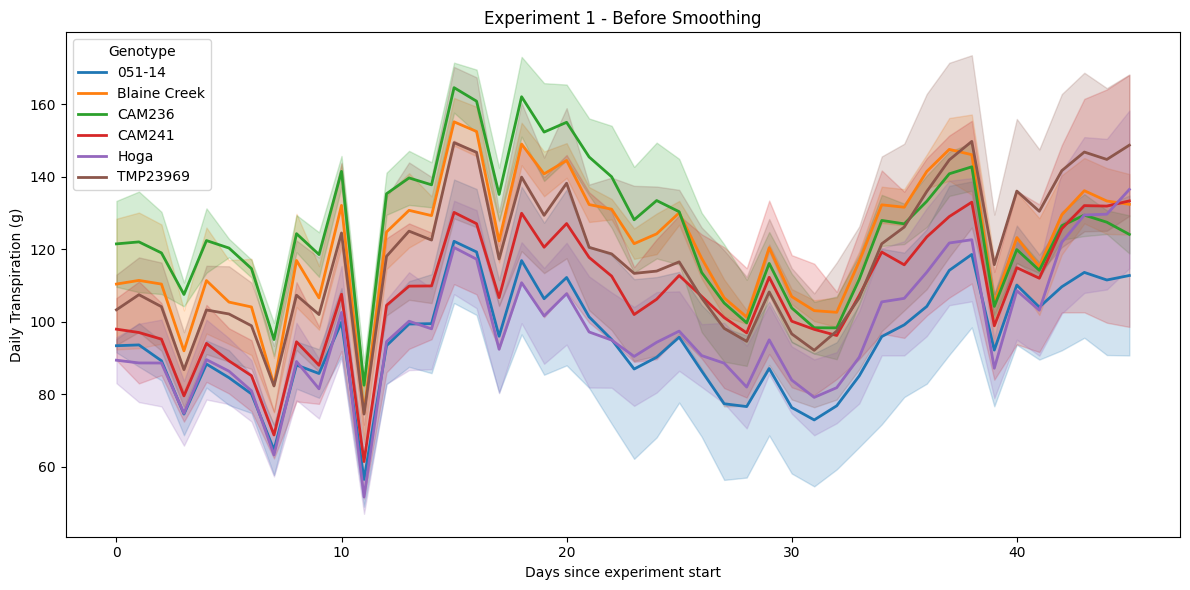

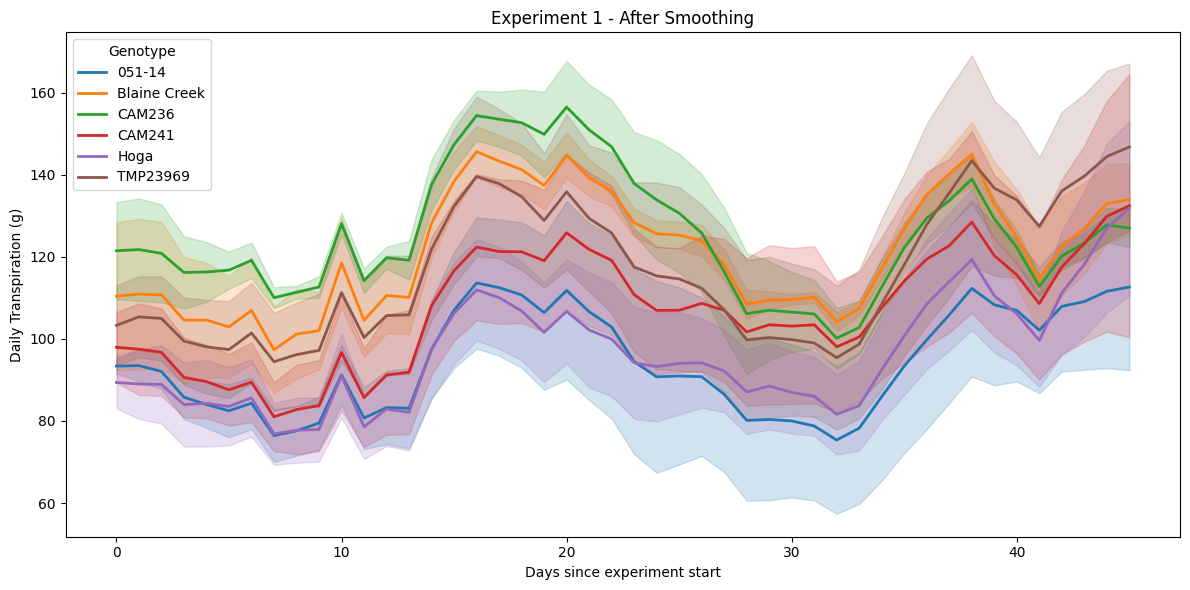

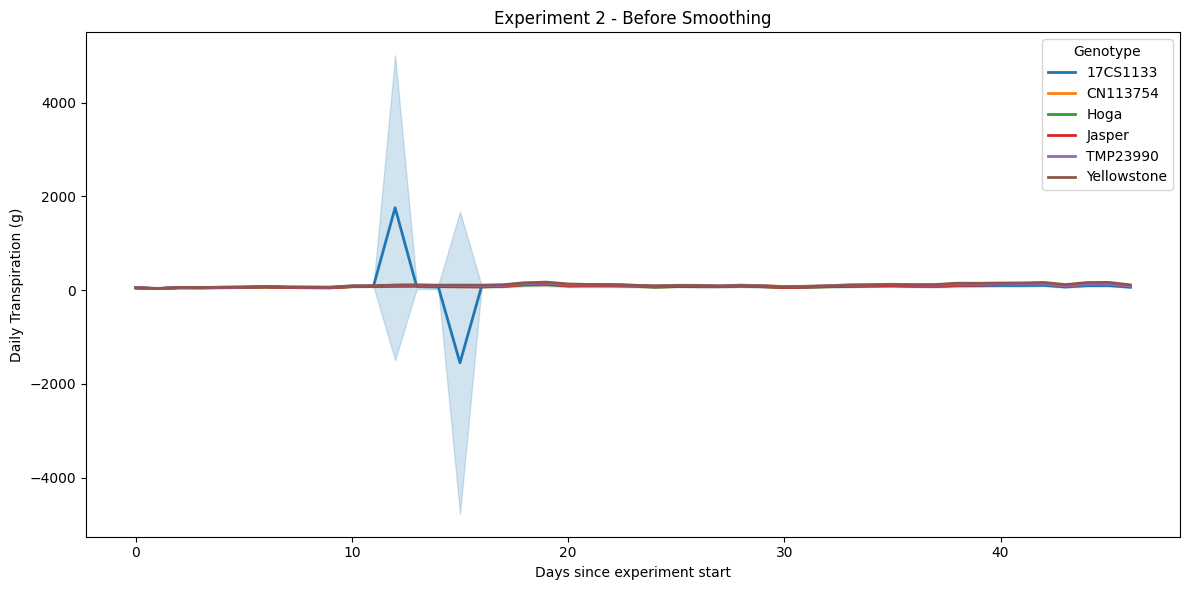

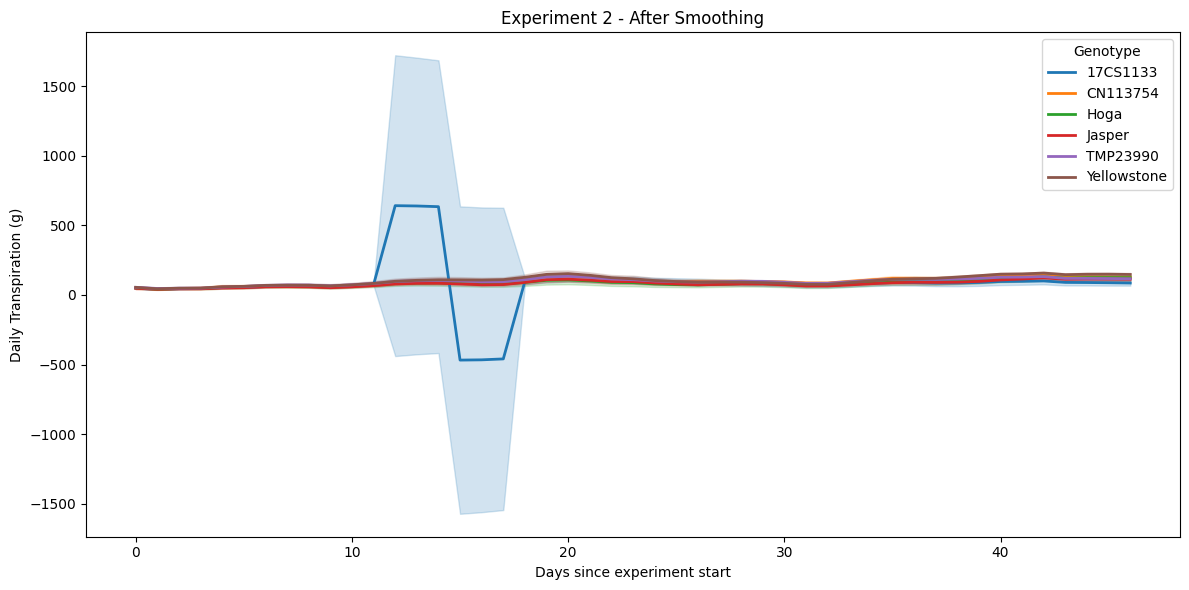

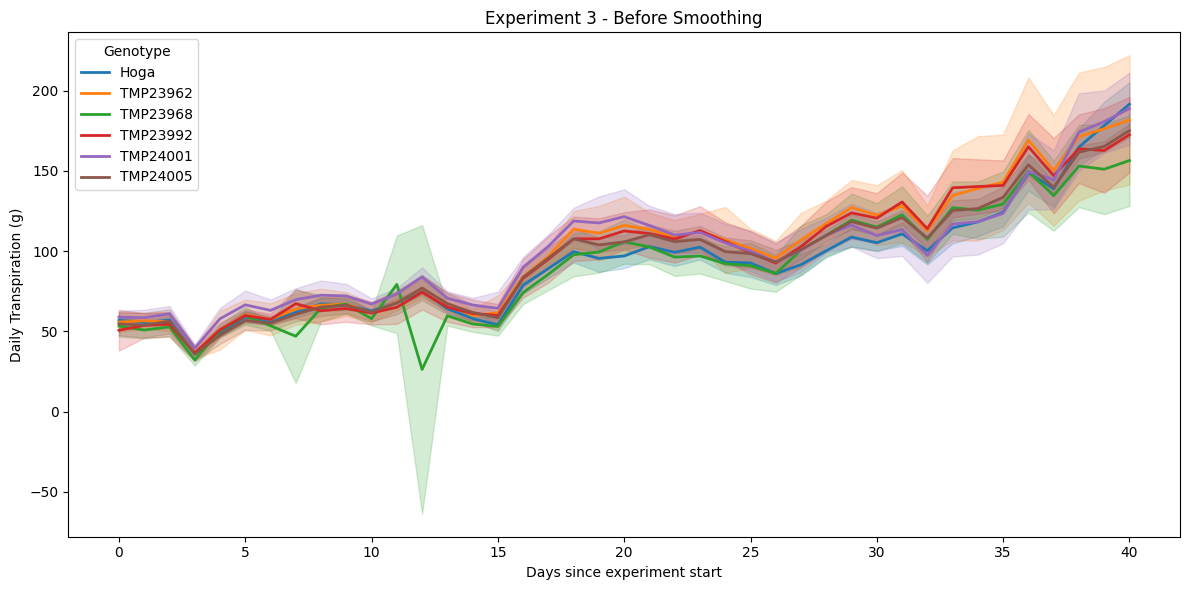

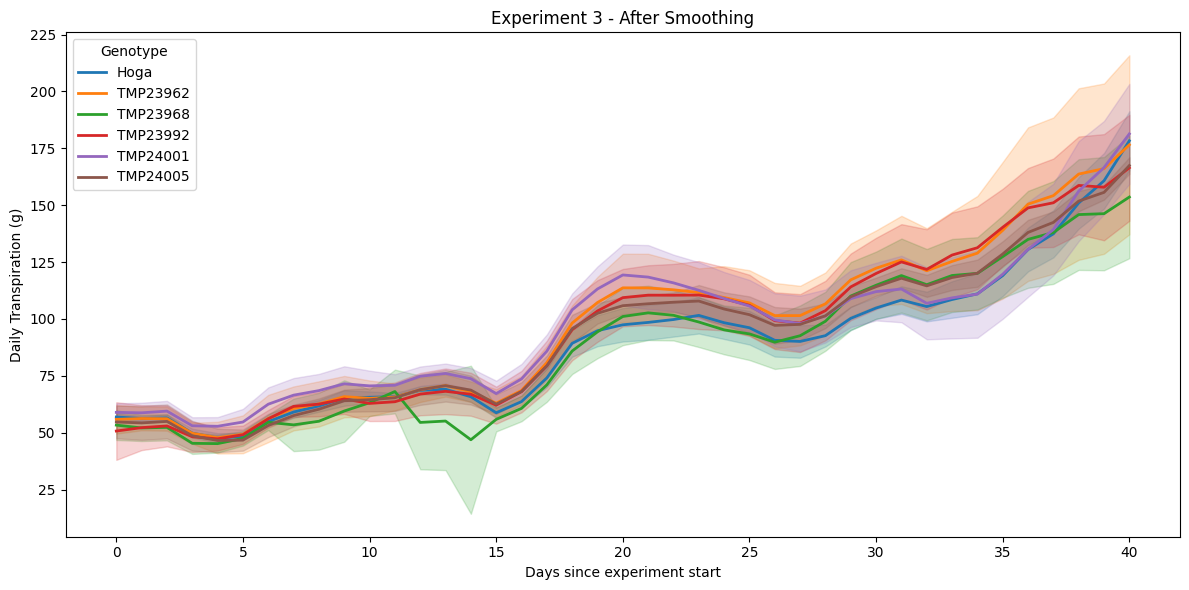

In [3]:
# 1.2 Data Loading and Processing


print("Loading data from Experiments:", EXPERIMENTS)

exp_transpiration_dataframes = {} # To store processed dataframes for each experiment

for exp_num in EXPERIMENTS:
    print(f"  Processing Experiment {exp_num}...")
    
    # 1. Define Paths
    transp_file = os.path.join(DATA_DIR, f'CamelinaMAGIC{exp_num}.0-DailyTranspiration.csv')
    weather_file = os.path.join(DATA_DIR, f'CamelinaMAGIC{exp_num}.0-WeatherStation.csv')

    try:
        df_transp = helpers.read_transpiration_csv(transp_file, RANDOMIZATION_FILE, exp_num)
        df_weather = helpers.read_weather_station_csv(weather_file, exp_num)

    except Exception as e:
        print(f"    Skipping Exp {exp_num} due to error: {e}")
        continue

    df_transp = df_transp[df_transp['Treatment'] == 'DR_100']     # Filter for DROUGHT Only Plants
    #helpers.plot_drought_transpiration_df(df_transp, title=f'Experiment {exp_num} - Before VPD Normalization')

    helpers.plot_drought_transpiration_df(df_transp, title=f'Experiment {exp_num} - Before Smoothing')
    #print(f"df_transp before smoothing for Exp {exp_num}:\n", df_transp.head())
    
    df_transp['Transp_original'] = df_transp['Transpiration']  # Keep original for comparison


    # Smooth Data (Rolling Average)

    # cols_to_smooth = ['Weight', 'Transpiration', 'Transp_Norm'] #old line
    cols_to_smooth = ['Transpiration']
    df_transp['Transpiration'] = df_transp.groupby('Sample')[cols_to_smooth].transform(   # Group by Sample to ensure we don't smooth across different plants
        lambda x: x.rolling(window=3, min_periods=1).mean()
    )
    helpers.plot_drought_transpiration_df(df_transp, title=f'Experiment {exp_num} - After Smoothing')
        
    #print(f"df_transp after smoothing for Exp {exp_num}:\n", df_transp.head())

    exp_transpiration_dataframes[exp_num] = df_transp # Store for later use.

print("Number of dataframes in the dict exp_transpiration_dataframes:", len(exp_transpiration_dataframes))



### Just to visualize important information for now

In [4]:
combined_df = pd.concat([d for d in exp_transpiration_dataframes.values()], ignore_index=True)

unique_samples = combined_df['Sample'].unique()
print(f"  Found \033[32m\033[1m{len(unique_samples)}\033[0m\033[m unique samples in all the experiments combined:\n ", unique_samples, "\n")

unique_genotypes = combined_df['Genotype'].unique()
print(f"  Found \033[32m\033[1m{len(unique_genotypes)}\033[0m\033[m unique genotypes in all the experiments combined:\n ", unique_genotypes, "\n")


for exp, df in exp_transpiration_dataframes.items():
    unique_exp_samples = df['Sample'].unique()
    print(f"  Found \033[32m\033[1m{len(unique_exp_samples)}\033[0m\033[m unique samples in experiment \033[32m\033[1m{exp}\033[0m\033[m:\n ", unique_exp_samples, "\n")
    
    unique_exp_genotypes = df['Genotype'].unique()
    print(f"  Found \033[32m\033[1m{len(unique_exp_genotypes)}\033[0m\033[m unique genotypes in experiment \033[32m\033[1m{exp}\033[0m\033[m:\n ", unique_exp_genotypes, "\n")


  Found 35 unique samples in all the experiments combined:
  ['Camelina06' 'Camelina07' 'Camelina08' 'Camelina09' 'Camelina10'
 'Camelina15' 'Camelina16' 'Camelina17' 'Camelina18' 'Camelina23'
 'Camelina24' 'Camelina25' 'Camelina26' 'Camelina31' 'Camelina32'
 'Camelina33' 'Camelina34' 'Camelina39' 'Camelina40' 'Camelina41'
 'Camelina42' 'Camelina47' 'Camelina48' 'Camelina49' 'Camelina50'
 'Camelina05' 'Camelina13' 'Camelina14' 'Camelina21' 'Camelina22'
 'Camelina29' 'Camelina30' 'Camelina37' 'Camelina38' 'Camelina46'] 

  Found 16 unique genotypes in all the experiments combined:
  ['Hoga' 'Blaine Creek' 'TMP23969' '051-14' 'CAM236' 'CAM241' 'Yellowstone'
 '17CS1133' 'CN113754' 'Jasper' 'TMP23990' 'TMP24001' 'TMP24005'
 'TMP23962' 'TMP23992' 'TMP23968'] 

  Found 25 unique samples in experiment 1:
  ['Camelina06' 'Camelina07' 'Camelina08' 'Camelina09' 'Camelina10'
 'Camelina15' 'Camelina16' 'Camelina17' 'Camelina18' 'Camelina23'
 'Camelina24' 'Camelina25' 'Camelina26' 'Camelina31' 'Cam

### Prepare Unified Dataset with All Samples (New Approach)

In [5]:
# Prepare unified dataset: pool all samples across all experiments and genotypes
# Each sample will have: [11 transpiration values, 16 genotype one-hot features, 3 experiment one-hot features]

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import numpy as np
import pandas as pd

INPUT_WINDOW = list(range(15, 26))   # Days 15-25 inclusive (11 timesteps)
RECOVERY_WINDOW = list(range(36, 41)) # Days 36-40 inclusive

print("Building unified dataset from all experiments and genotypes...")

# Collect all samples with their features and targets
all_samples_data = []

for exp in [1, 2, 3]:
    exp_df = exp_transpiration_dataframes.get(exp)
    if exp_df is None:
        continue
    
    # Group by sample to process each plant individually
    for sample_name, sample_df in exp_df.groupby('Sample'):
        sample_df_sorted = sample_df.sort_values('Days')
        
        # Get input window data (Days 15-25) - SMOOTHED transpiration
        input_data = sample_df_sorted[sample_df_sorted['Days'].isin(INPUT_WINDOW)]
        if len(input_data) < len(INPUT_WINDOW):
            continue  # Skip samples with incomplete input data
        
        # Extract SMOOTHED transpiration values for input window
        transp_features = input_data['Transpiration'].values  # Already smoothed in Cell 5
        
        # Get genotype
        genotype = sample_df['Genotype'].iloc[0]
        
        # Calculate target slope from recovery window (Days 36-40) - SMOOTHED data
        recovery_data = sample_df_sorted[sample_df_sorted['Days'].isin(RECOVERY_WINDOW)]
        if len(recovery_data) < 2:
            continue  # Skip samples without enough recovery data
        
        from scipy.stats import linregress
        target_slope = float(linregress(recovery_data['Days'], recovery_data['Transpiration']).slope)
        
        # Store all information
        all_samples_data.append({
            'Sample': sample_name,
            'Experiment': exp,
            'Genotype': genotype,
            'Transpiration_Features': transp_features,
            'Target_Slope': target_slope
        })

print(f"✓ Collected {len(all_samples_data)} samples total")

# Create feature matrix with one-hot encoded genotypes and experiments
unique_genotypes = sorted(list(set([s['Genotype'] for s in all_samples_data])))
print(f"✓ Found {len(unique_genotypes)} unique genotypes: {unique_genotypes}")

# Build feature matrix WITH ONE-HOT EXPERIMENTS
X_unified = []
y_unified = []
sample_info = []  # Keep track of sample metadata

for sample_data in all_samples_data:
    # Start with SMOOTHED transpiration features (11 values)
    features = list(sample_data['Transpiration_Features'])
    
    # Add one-hot encoded genotype (16 features)
    genotype_encoding = [1 if g == sample_data['Genotype'] else 0 for g in unique_genotypes]
    features.extend(genotype_encoding)
    
    # Add one-hot encoded experiment (3 features)
    exp_encoding = [1 if exp == sample_data['Experiment'] else 0 for exp in [1, 2, 3]]
    features.extend(exp_encoding)
    
    X_unified.append(features)
    y_unified.append(sample_data['Target_Slope'])
    sample_info.append({
        'Sample': sample_data['Sample'],
        'Experiment': sample_data['Experiment'],
        'Genotype': sample_data['Genotype']
    })

X_unified = np.array(X_unified)
y_unified = np.array(y_unified)

print(f"\n{'='*70}")
print(f"UNIFIED DATASET SUMMARY")
print(f"{'='*70}")
print(f"Total samples: {len(X_unified)}")
print(f"Feature dimensions: {X_unified.shape[1]} features")
print(f"  - Transpiration SMOOTHED (Days 15-25): 11 features")
print(f"  - Genotype (one-hot): {len(unique_genotypes)} features")
print(f"  - Experiment (one-hot): 3 features")
print(f"Target: Recovery slope from SMOOTHED data (Days 36-40)")
print(f"Target range: [{y_unified.min():.4f}, {y_unified.max():.4f}]")
print(f"Target mean: {y_unified.mean():.4f}")
print(f"Target std: {y_unified.std():.4f}")
print(f"{'='*70}\n")


Building unified dataset from all experiments and genotypes...
✓ Collected 76 samples total
✓ Found 16 unique genotypes: ['051-14', '17CS1133', 'Blaine Creek', 'CAM236', 'CAM241', 'CN113754', 'Hoga', 'Jasper', 'TMP23962', 'TMP23968', 'TMP23969', 'TMP23990', 'TMP23992', 'TMP24001', 'TMP24005', 'Yellowstone']

UNIFIED DATASET SUMMARY
Total samples: 76
Feature dimensions: 30 features
  - Transpiration SMOOTHED (Days 15-25): 11 features
  - Genotype (one-hot): 16 features
  - Experiment (one-hot): 3 features
Target: Recovery slope from SMOOTHED data (Days 36-40)
Target range: [-4.6503, 14.8983]
Target mean: 3.9402
Target std: 4.4983



In [10]:
# Train unified models using LOOCV on all samples
# Models: Linear Regression, Random Forest, LSTM
# Each model trains 76 times (once per sample), training on 75 and testing on 1
# Final metrics are computed by averaging performance across all 76 test samples

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
import numpy as np
import os
import pickle

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Create models directory
MODELS_DIR = 'models'
if not os.path.exists(MODELS_DIR):
    os.makedirs(MODELS_DIR)

print(f"Training unified models with LOOCV on {len(X_unified)} samples...")
print(f"Each fold: Train on {len(X_unified)-1} samples, Test on 1 sample")
print(f"Total folds: {len(X_unified)}\n")

# ============================================================================
# 1. LINEAR REGRESSION
# ============================================================================
print("="*70)
print("LINEAR REGRESSION")
print("="*70)


loo = LeaveOneOut()
lr_preds = []
lr_actuals = []
lr_sample_info = []

from sklearn.linear_model import Ridge

for train_idx, test_idx in loo.split(X_unified):
    X_train, X_test = X_unified[train_idx], X_unified[test_idx]
    y_train, y_test = y_unified[train_idx], y_unified[test_idx]
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train Linear Regression model
    model = lr = Ridge(alpha=10.0)
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)[0]
    
    lr_preds.append(y_pred)
    lr_actuals.append(y_test[0])
    lr_sample_info.append(sample_info[test_idx[0]])

# Calculate metrics by comparing all 76 predictions to actual values
lr_r2 = r2_score(lr_actuals, lr_preds)
lr_mse = mean_squared_error(lr_actuals, lr_preds)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(lr_actuals, lr_preds)

print(f"R² Score: {lr_r2:.4f}")
print(f"RMSE: {lr_rmse:.4f}")
print(f"MAE: {lr_mae:.4f}")

# Train final model on all data for deployment
scaler_final_lr = StandardScaler()
X_scaled_final = scaler_final_lr.fit_transform(X_unified)
final_model_lr = LinearRegression()
final_model_lr.fit(X_scaled_final, y_unified)

# Save model
lr_model_path = os.path.join(MODELS_DIR, 'LR_unified_model.pkl')
lr_scaler_path = os.path.join(MODELS_DIR, 'LR_unified_scaler.pkl')
with open(lr_model_path, 'wb') as f:
    pickle.dump(final_model_lr, f)
with open(lr_scaler_path, 'wb') as f:
    pickle.dump(scaler_final_lr, f)
print(f"✓ Saved: {lr_model_path}")
print(f"✓ Saved: {lr_scaler_path}\n")

# ============================================================================
# 2. RANDOM FOREST
# ============================================================================
print("="*70)
print("RANDOM FOREST")
print("="*70)

rf_preds = []
rf_actuals = []

for train_idx, test_idx in loo.split(X_unified):
    X_train, X_test = X_unified[train_idx], X_unified[test_idx]
    y_train, y_test = y_unified[train_idx], y_unified[test_idx]
    
    # Scale features for consistency
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train model
    model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10, min_samples_leaf=2)
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)[0]
    
    rf_preds.append(y_pred)
    rf_actuals.append(y_test[0])

# Calculate metrics by comparing all 76 predictions to actual values
rf_r2 = r2_score(rf_actuals, rf_preds)
rf_mse = mean_squared_error(rf_actuals, rf_preds)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(rf_actuals, rf_preds)

print(f"R² Score: {rf_r2:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE: {rf_mae:.4f}")

# Train final model on all data for deployment
scaler_final_rf = StandardScaler()
X_scaled_final_rf = scaler_final_rf.fit_transform(X_unified)
final_model_rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10, min_samples_leaf=2)
final_model_rf.fit(X_scaled_final_rf, y_unified)

# Save model
rf_model_path = os.path.join(MODELS_DIR, 'RF_unified_model.pkl')
rf_scaler_path = os.path.join(MODELS_DIR, 'RF_unified_scaler.pkl')
with open(rf_model_path, 'wb') as f:
    pickle.dump(final_model_rf, f)
with open(rf_scaler_path, 'wb') as f:
    pickle.dump(scaler_final_rf, f)
print(f"✓ Saved: {rf_model_path}")
print(f"✓ Saved: {rf_scaler_path}\n")

# ============================================================================
# 3. LSTM (PyTorch)
# ============================================================================
print("="*70)
print("LSTM")
print("="*70)

# Define LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, metadata_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        # Combine LSTM output with metadata features
        self.fc1 = nn.Linear(hidden_size + metadata_size, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(32, output_size)
    
    def forward(self, x_sequence, x_metadata):
        # x_sequence: (batch, seq_len, features) = (batch, 11, 1)
        # x_metadata: (batch, metadata_features) = (batch, 19) for genotype+experiment
        
        lstm_out, _ = self.lstm(x_sequence)
        lstm_out = lstm_out[:, -1, :]  # Take last timestep
        
        # Concatenate with metadata
        combined = torch.cat((lstm_out, x_metadata), dim=1)
        x = self.fc1(combined)
        x = self.relu(x)
        x = self.dropout(x)
        output = self.fc2(x)
        return output

# Prepare data for LSTM: separate time-series from metadata
X_sequence = X_unified[:, :11].reshape(-1, 11, 1)  # SMOOTHED Transpiration
X_metadata = X_unified[:, 11:]  # Genotype (16) + Experiment (3) = 19

lstm_preds = []
lstm_actuals = []

print("Training LSTM (this may take a few minutes)...")
for fold_num, (train_idx, test_idx) in enumerate(loo.split(X_unified), 1):
    if fold_num % 10 == 0:
        print(f"  Fold {fold_num}/{len(X_unified)}")
    
    X_seq_train, X_seq_test = X_sequence[train_idx], X_sequence[test_idx]
    X_meta_train, X_meta_test = X_metadata[train_idx], X_metadata[test_idx]
    y_train, y_test = y_unified[train_idx], y_unified[test_idx]
    
    # Convert to PyTorch tensors
    X_seq_train_t = torch.FloatTensor(X_seq_train)
    X_meta_train_t = torch.FloatTensor(X_meta_train)
    y_train_t = torch.FloatTensor(y_train)
    X_seq_test_t = torch.FloatTensor(X_seq_test)
    X_meta_test_t = torch.FloatTensor(X_meta_test)
    
    # Initialize model
    model = LSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, metadata_size=19)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    
    # Train
    model.train()
    for epoch in range(200):
        optimizer.zero_grad()
        outputs = model(X_seq_train_t, X_meta_train_t)
        loss = criterion(outputs.squeeze(), y_train_t)
        loss.backward()
        optimizer.step()
    
    # Predict
    model.eval()
    with torch.no_grad():
        y_pred = model(X_seq_test_t, X_meta_test_t).item()
    
    lstm_preds.append(y_pred)
    lstm_actuals.append(y_test[0])

# Calculate metrics by comparing all 76 predictions to actual values
lstm_r2 = r2_score(lstm_actuals, lstm_preds)
lstm_mse = mean_squared_error(lstm_actuals, lstm_preds)
lstm_rmse = np.sqrt(lstm_mse)
lstm_mae = mean_absolute_error(lstm_actuals, lstm_preds)

print(f"R² Score: {lstm_r2:.4f}")
print(f"RMSE: {lstm_rmse:.4f}")
print(f"MAE: {lstm_mae:.4f}")

# Train final LSTM model on all data for deployment
print("Training final LSTM model...")
X_seq_all = torch.FloatTensor(X_sequence)
X_meta_all = torch.FloatTensor(X_metadata)
y_all = torch.FloatTensor(y_unified)

final_model_lstm = LSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, metadata_size=19)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(final_model_lstm.parameters(), lr=0.01)

final_model_lstm.train()
for epoch in range(1000):
    optimizer.zero_grad()
    outputs = final_model_lstm(X_seq_all, X_meta_all)
    loss = criterion(outputs.squeeze(), y_all)
    loss.backward()
    optimizer.step()

# Save LSTM model
lstm_model_path = os.path.join(MODELS_DIR, 'LSTM_unified_model.pth')
torch.save(final_model_lstm.state_dict(), lstm_model_path)
print(f"✓ Saved: {lstm_model_path}\n")

# ============================================================================
# SUMMARY TABLE
# ============================================================================
print("="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)

results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'LSTM'],
    'R²': [lr_r2, rf_r2, lstm_r2],
    'RMSE': [lr_rmse, rf_rmse, lstm_rmse],
    'MAE': [lr_mae, rf_mae, lstm_mae],
    'Samples': [len(X_unified)] * 3,
    'Features': [X_unified.shape[1]] * 3
})

display(results_df.sort_values('R²', ascending=False).reset_index(drop=True))


Training unified models with LOOCV on 76 samples...
Each fold: Train on 75 samples, Test on 1 sample
Total folds: 76

LINEAR REGRESSION
R² Score: -9.2528
RMSE: 14.4036
MAE: 3.5331
✓ Saved: models\LR_unified_model.pkl
✓ Saved: models\LR_unified_scaler.pkl

RANDOM FOREST
R² Score: 0.6898
RMSE: 2.5053
MAE: 2.0257
✓ Saved: models\RF_unified_model.pkl
✓ Saved: models\RF_unified_scaler.pkl

LSTM
Training LSTM (this may take a few minutes)...
  Fold 10/76
  Fold 20/76
  Fold 30/76
  Fold 40/76
  Fold 50/76
  Fold 60/76
  Fold 70/76
R² Score: 0.7367
RMSE: 2.3083
MAE: 1.9047
Training final LSTM model...
✓ Saved: models\LSTM_unified_model.pth

MODEL COMPARISON SUMMARY


,Model,R²,RMSE,MAE,Samples,Features
0,LSTM,0.736675,2.308332,1.904675,76,30
1,Random Forest,0.689811,2.505330,2.025715,76,30
2,Linear Regression,-9.252754,14.403637,3.533078,76,30


## GRU Model

In [12]:
# ============================================================================
# 4. GRU (PyTorch) - New Model
# ============================================================================
print("="*70)
print("GRU")
print("="*70)

# Define GRU model (similar architecture to LSTM)
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, metadata_size):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        # Combine GRU output with metadata features
        self.fc1 = nn.Linear(hidden_size + metadata_size, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(32, output_size)
    
    def forward(self, x_sequence, x_metadata):
        # x_sequence: (batch, seq_len, features) = (batch, 11, 1)
        # x_metadata: (batch, metadata_features) = (batch, 19) for genotype+experiment
        
        gru_out, _ = self.gru(x_sequence)
        gru_out = gru_out[:, -1, :]  # Take last timestep
        
        # Concatenate with metadata
        combined = torch.cat((gru_out, x_metadata), dim=1)
        x = self.fc1(combined)
        x = self.relu(x)
        x = self.dropout(x)
        output = self.fc2(x)
        return output

# Use same data preparation as LSTM (already defined as X_sequence and X_metadata)
gru_preds = []
gru_actuals = []

print("Training GRU (this may take a few minutes)...")
for fold_num, (train_idx, test_idx) in enumerate(loo.split(X_unified), 1):
    if fold_num % 10 == 0:
        print(f"  Fold {fold_num}/{len(X_unified)}")
    
    X_seq_train, X_seq_test = X_sequence[train_idx], X_sequence[test_idx]
    X_meta_train, X_meta_test = X_metadata[train_idx], X_metadata[test_idx]
    y_train, y_test = y_unified[train_idx], y_unified[test_idx]
    
    # Convert to PyTorch tensors
    X_seq_train_t = torch.FloatTensor(X_seq_train)
    X_meta_train_t = torch.FloatTensor(X_meta_train)
    y_train_t = torch.FloatTensor(y_train)
    X_seq_test_t = torch.FloatTensor(X_seq_test)
    X_meta_test_t = torch.FloatTensor(X_meta_test)
    
    # Initialize model
    model = GRUModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, metadata_size=19)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    
    # Train
    model.train()
    for epoch in range(200):
        optimizer.zero_grad()
        outputs = model(X_seq_train_t, X_meta_train_t)
        loss = criterion(outputs.squeeze(), y_train_t)
        loss.backward()
        optimizer.step()
    
    # Predict
    model.eval()
    with torch.no_grad():
        y_pred = model(X_seq_test_t, X_meta_test_t).item()
    
    gru_preds.append(y_pred)
    gru_actuals.append(y_test[0])

# Calculate metrics by comparing all 76 predictions to actual values
gru_r2 = r2_score(gru_actuals, gru_preds)
gru_mse = mean_squared_error(gru_actuals, gru_preds)
gru_rmse = np.sqrt(gru_mse)
gru_mae = mean_absolute_error(gru_actuals, gru_preds)

print(f"R² Score: {gru_r2:.4f}")
print(f"RMSE: {gru_rmse:.4f}")
print(f"MAE: {gru_mae:.4f}")

# Train final GRU model on all data for deployment
print("Training final GRU model...")
X_seq_all = torch.FloatTensor(X_sequence)
X_meta_all = torch.FloatTensor(X_metadata)
y_all = torch.FloatTensor(y_unified)

final_model_gru = GRUModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, metadata_size=19)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(final_model_gru.parameters(), lr=0.01)

final_model_gru.train()
for epoch in range(200):
    optimizer.zero_grad()
    outputs = final_model_gru(X_seq_all, X_meta_all)
    loss = criterion(outputs.squeeze(), y_all)
    loss.backward()
    optimizer.step()

# Save GRU model
gru_model_path = os.path.join(MODELS_DIR, 'GRU_unified_model.pth')
torch.save(final_model_gru.state_dict(), gru_model_path)
print(f"✓ Saved: {gru_model_path}\n")

# ============================================================================
# UPDATED SUMMARY TABLE (with GRU)
# ============================================================================
print("="*70)
print("MODEL COMPARISON SUMMARY (UPDATED WITH GRU)")
print("="*70)

results_df_updated = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'LSTM', 'GRU'],
    'R²': [lr_r2, rf_r2, lstm_r2, gru_r2],
    'RMSE': [lr_rmse, rf_rmse, lstm_rmse, gru_rmse],
    'MAE': [lr_mae, rf_mae, lstm_mae, gru_mae],
    'Samples': [len(X_unified)] * 4,
    'Features': [X_unified.shape[1]] * 4
})

display(results_df_updated.sort_values('R²', ascending=False).reset_index(drop=True))

GRU
Training GRU (this may take a few minutes)...
  Fold 10/76
  Fold 20/76
  Fold 30/76
  Fold 40/76
  Fold 50/76
  Fold 60/76
  Fold 70/76
R² Score: 0.7304
RMSE: 2.3355
MAE: 1.9759
Training final GRU model...
✓ Saved: models\GRU_unified_model.pth

MODEL COMPARISON SUMMARY (UPDATED WITH GRU)


,Model,R²,RMSE,MAE,Samples,Features
0,LSTM,0.736675,2.308332,1.904675,76,30
1,GRU,0.730444,2.335480,1.975907,76,30
2,Random Forest,0.689811,2.505330,2.025715,76,30
3,Linear Regression,-9.252754,14.403637,3.533078,76,30


## Bidirectional LSTM Model

In [13]:
# ============================================================================
# 5. BIDIRECTIONAL LSTM (PyTorch)
# ============================================================================
print("="*70)
print("BIDIRECTIONAL LSTM")
print("="*70)

# Define Bidirectional LSTM model
class BiLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, metadata_size):
        super(BiLSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # Bidirectional LSTM: outputs hidden_size * 2
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2, bidirectional=True)
        # Combine BiLSTM output (hidden_size*2) with metadata features
        self.fc1 = nn.Linear(hidden_size * 2 + metadata_size, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(32, output_size)
    
    def forward(self, x_sequence, x_metadata):
        # x_sequence: (batch, seq_len, features) = (batch, 11, 1)
        # x_metadata: (batch, metadata_features) = (batch, 19) for genotype+experiment
        
        lstm_out, _ = self.lstm(x_sequence)
        lstm_out = lstm_out[:, -1, :]  # Take last timestep (contains both forward and backward)
        
        # Concatenate with metadata
        combined = torch.cat((lstm_out, x_metadata), dim=1)
        x = self.fc1(combined)
        x = self.relu(x)
        x = self.dropout(x)
        output = self.fc2(x)
        return output

# Use same data preparation as LSTM (already defined as X_sequence and X_metadata)
bilstm_preds = []
bilstm_actuals = []

print("Training Bidirectional LSTM (this may take a few minutes)...")
for fold_num, (train_idx, test_idx) in enumerate(loo.split(X_unified), 1):
    if fold_num % 10 == 0:
        print(f"  Fold {fold_num}/{len(X_unified)}")
    
    X_seq_train, X_seq_test = X_sequence[train_idx], X_sequence[test_idx]
    X_meta_train, X_meta_test = X_metadata[train_idx], X_metadata[test_idx]
    y_train, y_test = y_unified[train_idx], y_unified[test_idx]
    
    # Convert to PyTorch tensors
    X_seq_train_t = torch.FloatTensor(X_seq_train)
    X_meta_train_t = torch.FloatTensor(X_meta_train)
    y_train_t = torch.FloatTensor(y_train)
    X_seq_test_t = torch.FloatTensor(X_seq_test)
    X_meta_test_t = torch.FloatTensor(X_meta_test)
    
    # Initialize model
    model = BiLSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, metadata_size=19)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    
    # Train
    model.train()
    for epoch in range(200):
        optimizer.zero_grad()
        outputs = model(X_seq_train_t, X_meta_train_t)
        loss = criterion(outputs.squeeze(), y_train_t)
        loss.backward()
        optimizer.step()
    
    # Predict
    model.eval()
    with torch.no_grad():
        y_pred = model(X_seq_test_t, X_meta_test_t).item()
    
    bilstm_preds.append(y_pred)
    bilstm_actuals.append(y_test[0])

# Calculate metrics by comparing all 76 predictions to actual values
bilstm_r2 = r2_score(bilstm_actuals, bilstm_preds)
bilstm_mse = mean_squared_error(bilstm_actuals, bilstm_preds)
bilstm_rmse = np.sqrt(bilstm_mse)
bilstm_mae = mean_absolute_error(bilstm_actuals, bilstm_preds)

print(f"R² Score: {bilstm_r2:.4f}")
print(f"RMSE: {bilstm_rmse:.4f}")
print(f"MAE: {bilstm_mae:.4f}")

# Train final Bidirectional LSTM model on all data for deployment
print("Training final Bidirectional LSTM model...")
X_seq_all = torch.FloatTensor(X_sequence)
X_meta_all = torch.FloatTensor(X_metadata)
y_all = torch.FloatTensor(y_unified)

final_model_bilstm = BiLSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, metadata_size=19)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(final_model_bilstm.parameters(), lr=0.01)

final_model_bilstm.train()
for epoch in range(1000):
    optimizer.zero_grad()
    outputs = final_model_bilstm(X_seq_all, X_meta_all)
    loss = criterion(outputs.squeeze(), y_all)
    loss.backward()
    optimizer.step()

# Save Bidirectional LSTM model
bilstm_model_path = os.path.join(MODELS_DIR, 'BiLSTM_unified_model.pth')
torch.save(final_model_bilstm.state_dict(), bilstm_model_path)
print(f"✓ Saved: {bilstm_model_path}\n")

# ============================================================================
# FINAL SUMMARY TABLE (with all models)
# ============================================================================
print("="*70)
print("COMPLETE MODEL COMPARISON SUMMARY")
print("="*70)

results_df_complete = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'LSTM', 'GRU', 'Bidirectional LSTM'],
    'R²': [lr_r2, rf_r2, lstm_r2, gru_r2, bilstm_r2],
    'RMSE': [lr_rmse, rf_rmse, lstm_rmse, gru_rmse, bilstm_rmse],
    'MAE': [lr_mae, rf_mae, lstm_mae, gru_mae, bilstm_mae],
    'Samples': [len(X_unified)] * 5,
    'Features': [X_unified.shape[1]] * 5
})

display(results_df_complete.sort_values('R²', ascending=False).reset_index(drop=True))

BIDIRECTIONAL LSTM
Training Bidirectional LSTM (this may take a few minutes)...
  Fold 10/76
  Fold 10/76
  Fold 20/76
  Fold 20/76
  Fold 30/76
  Fold 30/76
  Fold 40/76
  Fold 40/76
  Fold 50/76
  Fold 50/76
  Fold 60/76
  Fold 60/76
  Fold 70/76
  Fold 70/76
R² Score: 0.7103
RMSE: 2.4214
MAE: 2.0387
Training final Bidirectional LSTM model...
R² Score: 0.7103
RMSE: 2.4214
MAE: 2.0387
Training final Bidirectional LSTM model...
✓ Saved: models\BiLSTM_unified_model.pth

COMPLETE MODEL COMPARISON SUMMARY
✓ Saved: models\BiLSTM_unified_model.pth

COMPLETE MODEL COMPARISON SUMMARY


,Model,R²,RMSE,MAE,Samples,Features
0,LSTM,0.736675,2.308332,1.904675,76,30
1,GRU,0.730444,2.335480,1.975907,76,30
2,Bidirectional LSTM,0.710258,2.421351,2.038655,76,30
3,Random Forest,0.689811,2.505330,2.025715,76,30
4,Linear Regression,-9.252754,14.403637,3.533078,76,30


## Generate first Augmented set

In [17]:
# ============================================================================
# DATA AUGMENTATION
# ============================================================================
print("="*70)
print("DATA AUGMENTATION")
print("="*70)

import numpy as np
from copy import deepcopy

# Set seed for reproducibility
np.random.seed(42)

# Augmentation parameters
AUGMENTATIONS_PER_SAMPLE = 3  # Generate 3 augmented versions per original sample
SCALE_RANGE = (0.85, 1.15)    # Random scaling factor range (±15%)
JITTER_STD = 0.02              # Standard deviation for Gaussian jitter (2% of mean)
MIX_PROBABILITY = 0.3          # 30% chance to mix with another sample of same genotype

print(f"Original dataset: {len(X_unified)} samples")
print(f"Augmentations per sample: {AUGMENTATIONS_PER_SAMPLE}")
print(f"Expected augmented dataset size: {len(X_unified) * (1 + AUGMENTATIONS_PER_SAMPLE)} samples\n")

# Store augmented data
X_augmented_list = []
y_augmented_list = []
sample_info_augmented_list = []

# First, add all original samples
for i in range(len(X_unified)):
    X_augmented_list.append(X_unified[i].copy())
    y_augmented_list.append(y_unified[i])
    sample_info_augmented_list.append(deepcopy(sample_info[i]))

# Group samples by genotype for pattern mixing
genotype_groups = {}
for idx, info in enumerate(sample_info):
    genotype = info['Genotype']
    if genotype not in genotype_groups:
        genotype_groups[genotype] = []
    genotype_groups[genotype].append(idx)

print("Generating augmented samples...")
augmentation_count = 0

for original_idx in range(len(X_unified)):
    original_x = X_unified[original_idx].copy()
    original_y = y_unified[original_idx]
    original_info = sample_info[original_idx]
    genotype = original_info['Genotype']
    
    # Extract time series (Days 15-25) and metadata separately
    time_series = original_x[:11]  # Transpiration values
    metadata = original_x[11:]     # Genotype + Experiment one-hot (16 + 3 = 19)
    
    for aug_num in range(AUGMENTATIONS_PER_SAMPLE):
        augmented_time_series = time_series.copy()
        augmented_y = original_y
        
        # Augmentation 1: Random Scaling
        # Scale the time series while maintaining relative patterns
        scale_factor = np.random.uniform(*SCALE_RANGE)
        augmented_time_series = augmented_time_series * scale_factor
        augmented_y = augmented_y * scale_factor  # Scale target proportionally
        
        # Augmentation 2: Random Jitter
        # Add small Gaussian noise to simulate measurement variations
        mean_val = np.mean(np.abs(augmented_time_series))
        jitter = np.random.normal(0, mean_val * JITTER_STD, size=augmented_time_series.shape)
        augmented_time_series = augmented_time_series + jitter

        # Augmentation 3: Pattern Mixing (with same genotype only)
        # Blend with another sample of the same genotype to create hybrid patterns
        if np.random.random() < MIX_PROBABILITY and len(genotype_groups[genotype]) > 1:
            # Select a different sample from the same genotype
            same_genotype_indices = [idx for idx in genotype_groups[genotype] if idx != original_idx]
            if same_genotype_indices:
                mix_idx = np.random.choice(same_genotype_indices)
                mix_time_series = X_unified[mix_idx][:11]
                mix_y = y_unified[mix_idx]
                
                # Blend with random weight (70-30 to 30-70)
                mix_weight = np.random.uniform(0.3, 0.7)
                augmented_time_series = (1 - mix_weight) * augmented_time_series + mix_weight * mix_time_series
                augmented_y = (1 - mix_weight) * augmented_y + mix_weight * mix_y
        
        # Ensure no negative values (transpiration cannot be negative)
        augmented_time_series = np.maximum(augmented_time_series, 0)
        
        # Combine augmented time series with original metadata
        augmented_x = np.concatenate([augmented_time_series, metadata])
        
        # Add to augmented dataset
        X_augmented_list.append(augmented_x)
        y_augmented_list.append(augmented_y)
        
        # Create augmented sample info with marker
        augmented_info = deepcopy(original_info)
        augmented_info['Sample'] = f"{original_info['Sample']}_aug{aug_num+1}"
        sample_info_augmented_list.append(augmented_info)
        
        augmentation_count += 1

# Convert to numpy arrays
X_unified_augmented = np.array(X_augmented_list)
y_unified_augmented = np.array(y_augmented_list)
sample_info_augmented = sample_info_augmented_list

print(f"✓ Generated {augmentation_count} new augmented samples")
print(f"\n{'='*70}")
print(f"AUGMENTED DATASET SUMMARY")
print(f"{'='*70}")
print(f"Original samples: {len(X_unified)}")
print(f"Augmented samples: {len(X_unified_augmented)}")
print(f"Increase: {len(X_unified_augmented) / len(X_unified):.1f}x")
print(f"Feature dimensions: {X_unified_augmented.shape[1]} features (unchanged)")
print(f"Target range: [{y_unified_augmented.min():.4f}, {y_unified_augmented.max():.4f}]")
print(f"Target mean: {y_unified_augmented.mean():.4f} (original: {y_unified.mean():.4f})")
print(f"Target std: {y_unified_augmented.std():.4f} (original: {y_unified.std():.4f})")
print(f"{'='*70}\n")

print("To use augmented data in training cells, replace:")
print("  X_unified → X_unified_augmented")
print("  y_unified → y_unified_augmented")
print("  sample_info → sample_info_augmented")

DATA AUGMENTATION
Original dataset: 76 samples
Augmentations per sample: 3
Expected augmented dataset size: 304 samples

Generating augmented samples...
✓ Generated 228 new augmented samples

AUGMENTED DATASET SUMMARY
Original samples: 76
Augmented samples: 304
Increase: 4.0x
Feature dimensions: 30 features (unchanged)
Target range: [-5.1944, 15.5984]
Target mean: 3.9175 (original: 3.9402)
Target std: 4.3683 (original: 4.4983)

To use augmented data in training cells, replace:
  X_unified → X_unified_augmented
  y_unified → y_unified_augmented
  sample_info → sample_info_augmented


## Augmented Data training and Model Comparison

In [18]:
# ============================================================================
# 6. ALL MODELS ON AUGMENTED DATA + COMPARISON WITH ORIGINAL RESULTS
# ============================================================================
print('='*70)
print('MODELS ON AUGMENTED DATA (LOOCV)')
print('='*70)

# Preconditions: Augmented variables must exist:
#   X_unified_augmented, y_unified_augmented, sample_info_augmented
# If not, abort gracefully.
needed_vars = ['X_unified_augmented', 'y_unified_augmented', 'sample_info_augmented']
for v in needed_vars:
    if v not in globals():
        raise RuntimeError(f"Augmented dataset variable '{v}' not found. Run the augmentation cell first.")

print(f"Original samples: {len(X_unified)} | Augmented samples: {len(X_unified_augmented)}")

from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import os

np.random.seed(42)
torch.manual_seed(42)

# --- Helper functions ---

def loocv_tabular(model_ctor, X, y, scale=True):
    loo = LeaveOneOut()
    preds, actuals = [], []
    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        if scale:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
        model = model_ctor()
        model.fit(X_train, y_train)
        pred = model.predict(X_test)[0]
        preds.append(pred)
        actuals.append(y_test[0])
    r2 = r2_score(actuals, preds)
    mse = mean_squared_error(actuals, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actuals, preds)
    return r2, rmse, mae

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, metadata_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc1 = nn.Linear(hidden_size + metadata_size, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(32, output_size)
    def forward(self, x_seq, x_meta):
        out, _ = self.lstm(x_seq)
        out = out[:, -1, :]
        x = torch.cat((out, x_meta), dim=1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        return self.fc2(x)

class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, metadata_size):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc1 = nn.Linear(hidden_size + metadata_size, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(32, output_size)
    def forward(self, x_seq, x_meta):
        out, _ = self.gru(x_seq)
        out = out[:, -1, :]
        x = torch.cat((out, x_meta), dim=1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        return self.fc2(x)

class BiLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, metadata_size):
        super(BiLSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2, bidirectional=True)
        self.fc1 = nn.Linear(hidden_size*2 + metadata_size, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(32, output_size)
    def forward(self, x_seq, x_meta):
        out, _ = self.lstm(x_seq)
        out = out[:, -1, :]
        x = torch.cat((out, x_meta), dim=1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        return self.fc2(x)

# --- Sequence LOOCV helper ---

def loocv_sequence(model_class, X_seq, X_meta, y, hidden_size=64, num_layers=2, metadata_size=19, epochs=120, lr=0.01):
    loo = LeaveOneOut()
    preds, actuals = [], []
    criterion = nn.MSELoss()
    for fold_num, (train_idx, test_idx) in enumerate(loo.split(X_seq), 1):
        X_seq_train, X_seq_test = X_seq[train_idx], X_seq[test_idx]
        X_meta_train, X_meta_test = X_meta[train_idx], X_meta[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        X_seq_train_t = torch.FloatTensor(X_seq_train)
        X_seq_test_t = torch.FloatTensor(X_seq_test)
        X_meta_train_t = torch.FloatTensor(X_meta_train)
        X_meta_test_t = torch.FloatTensor(X_meta_test)
        y_train_t = torch.FloatTensor(y_train)
        model = model_class(input_size=1, hidden_size=hidden_size, num_layers=num_layers, output_size=1, metadata_size=metadata_size)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        model.train()
        for _ in range(epochs):
            optimizer.zero_grad()
            out = model(X_seq_train_t, X_meta_train_t).squeeze()
            loss = criterion(out, y_train_t)
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            pred = model(X_seq_test_t, X_meta_test_t).item()
        preds.append(pred)
        actuals.append(y_test[0])
    r2 = r2_score(actuals, preds)
    mse = mean_squared_error(actuals, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actuals, preds)
    return r2, rmse, mae

# Prepare augmented sequence & metadata splits
X_sequence_aug = X_unified_augmented[:, :11].reshape(-1, 11, 1)
X_metadata_aug = X_unified_augmented[:, 11:]
y_aug = y_unified_augmented
metadata_size = X_metadata_aug.shape[1]

print('Running LOOCV on augmented dataset... (This can take time)')

# Tabular models (use Ridge for linear robustness to augmented scaling)
aug_lr_r2, aug_lr_rmse, aug_lr_mae = loocv_tabular(lambda: Ridge(alpha=10.0), X_unified_augmented, y_aug, scale=True)
aug_rf_r2, aug_rf_rmse, aug_rf_mae = loocv_tabular(lambda: RandomForestRegressor(n_estimators=120, random_state=42, max_depth=12, min_samples_leaf=2), X_unified_augmented, y_aug, scale=True)

# Sequence models
SEQ_EPOCHS = 120  # Reduced per-fold epochs for efficiency on larger augmented set
aug_lstm_r2, aug_lstm_rmse, aug_lstm_mae = loocv_sequence(LSTMModel, X_sequence_aug, X_metadata_aug, y_aug, metadata_size=metadata_size, epochs=SEQ_EPOCHS)
aug_gru_r2, aug_gru_rmse, aug_gru_mae = loocv_sequence(GRUModel, X_sequence_aug, X_metadata_aug, y_aug, metadata_size=metadata_size, epochs=SEQ_EPOCHS)
aug_bilstm_r2, aug_bilstm_rmse, aug_bilstm_mae = loocv_sequence(BiLSTMModel, X_sequence_aug, X_metadata_aug, y_aug, metadata_size=metadata_size, epochs=SEQ_EPOCHS)

print('\nAugmented LOOCV complete.')

# Build comparison table (original metrics must exist from prior cells: lr_r2, rf_r2, lstm_r2, gru_r2, bilstm_r2)
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression (Ridge)', 'Random Forest', 'LSTM', 'GRU', 'BiLSTM'],
    'R2_Original': [lr_r2, rf_r2, lstm_r2, gru_r2, bilstm_r2],
    'RMSE_Original': [lr_rmse, rf_rmse, lstm_rmse, gru_rmse, bilstm_rmse],
    'MAE_Original': [lr_mae, rf_mae, lstm_mae, gru_mae, bilstm_mae],
    'R2_Augmented': [aug_lr_r2, aug_rf_r2, aug_lstm_r2, aug_gru_r2, aug_bilstm_r2],
    'RMSE_Augmented': [aug_lr_rmse, aug_rf_rmse, aug_lstm_rmse, aug_gru_rmse, aug_bilstm_rmse],
    'MAE_Augmented': [aug_lr_mae, aug_rf_mae, aug_lstm_mae, aug_gru_mae, aug_bilstm_mae],
    'Original_Samples': [len(X_unified)]*5,
    'Augmented_Samples': [len(X_unified_augmented)]*5
})

print('\n' + '='*70)
print('ORIGINAL vs AUGMENTED DATASET PERFORMANCE')
print('='*70)
from IPython.display import display
# Sort by Augmented R2 descending to see best improvement
display(comparison_df.sort_values('R2_Augmented', ascending=False).reset_index(drop=True))

# Simple improvement indicators
comparison_df['R2_Improvement'] = comparison_df['R2_Augmented'] - comparison_df['R2_Original']
print('\nTop R2 improvements:')
print(comparison_df[['Model','R2_Original','R2_Augmented','R2_Improvement']].sort_values('R2_Improvement', ascending=False).to_string(index=False))

print('\nDone.')

MODELS ON AUGMENTED DATA (LOOCV)
Original samples: 76 | Augmented samples: 304
Running LOOCV on augmented dataset... (This can take time)

Augmented LOOCV complete.

ORIGINAL vs AUGMENTED DATASET PERFORMANCE

Augmented LOOCV complete.

ORIGINAL vs AUGMENTED DATASET PERFORMANCE


,Model,R2_Original,RMSE_Original,MAE_Original,R2_Augmented,RMSE_Augmented,MAE_Augmented,Original_Samples,Augmented_Samples
0,Random Forest,0.689811,2.505330,2.025715,0.873774,1.551977,1.158302,76,304
1,GRU,0.730444,2.335480,1.975907,0.783400,2.033014,1.643047,76,304
2,LSTM,0.736675,2.308332,1.904675,0.780865,2.044874,1.668737,76,304
3,BiLSTM,0.710258,2.421351,2.038655,0.771199,2.089490,1.710458,76,304
4,Linear Regression (Ridge),-9.252754,14.403637,3.533078,-0.005085,4.379379,1.742485,76,304



Top R2 improvements:
                    Model  R2_Original  R2_Augmented  R2_Improvement
Linear Regression (Ridge)    -9.252754     -0.005085        9.247669
            Random Forest     0.689811      0.873774        0.183963
                   BiLSTM     0.710258      0.771199        0.060941
                      GRU     0.730444      0.783400        0.052956
                     LSTM     0.736675      0.780865        0.044191

Done.


In [20]:
# ============================================================================
# SAVE AUGMENTED MODELS (Final training on full augmented dataset)
# ============================================================================
print('='*70)
print('TRAINING AND SAVING FINAL MODELS ON AUGMENTED DATA')
print('='*70)

import pickle
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# This trains final models on ALL augmented data (no cross-validation)
# Much faster than LOOCV - should take ~5-10 minutes total

# 1. LINEAR REGRESSION (Ridge)
print('\n1. Training final Ridge model...')
scaler_lr_aug = StandardScaler()
X_scaled_lr = scaler_lr_aug.fit_transform(X_unified_augmented)
final_lr_aug = Ridge(alpha=10.0)
final_lr_aug.fit(X_scaled_lr, y_unified_augmented)

lr_aug_path = os.path.join(MODELS_DIR, 'LR_unified_model_augmented.pkl')
lr_scaler_aug_path = os.path.join(MODELS_DIR, 'LR_unified_scaler_augmented.pkl')
with open(lr_aug_path, 'wb') as f:
    pickle.dump(final_lr_aug, f)
with open(lr_scaler_aug_path, 'wb') as f:
    pickle.dump(scaler_lr_aug, f)
print(f'✓ Saved: {lr_aug_path}')
print(f'✓ Saved: {lr_scaler_aug_path}')

# 2. RANDOM FOREST
print('\n2. Training final Random Forest model...')
scaler_rf_aug = StandardScaler()
X_scaled_rf = scaler_rf_aug.fit_transform(X_unified_augmented)
final_rf_aug = RandomForestRegressor(n_estimators=120, random_state=42, max_depth=12, min_samples_leaf=2)
final_rf_aug.fit(X_scaled_rf, y_unified_augmented)

rf_aug_path = os.path.join(MODELS_DIR, 'RF_unified_model_augmented.pkl')
rf_scaler_aug_path = os.path.join(MODELS_DIR, 'RF_unified_scaler_augmented.pkl')
with open(rf_aug_path, 'wb') as f:
    pickle.dump(final_rf_aug, f)
with open(rf_scaler_aug_path, 'wb') as f:
    pickle.dump(scaler_rf_aug, f)
print(f'✓ Saved: {rf_aug_path}')
print(f'✓ Saved: {rf_scaler_aug_path}')

# Prepare sequence data for PyTorch models
X_seq_all_aug = torch.FloatTensor(X_sequence_aug)
X_meta_all_aug = torch.FloatTensor(X_metadata_aug)
y_all_aug = torch.FloatTensor(y_unified_augmented)

# 3. LSTM
print('\n3. Training final LSTM model (1000 epochs)...')
final_lstm_aug = LSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, metadata_size=19)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(final_lstm_aug.parameters(), lr=0.01)

final_lstm_aug.train()
for epoch in range(1000):
    if (epoch + 1) % 200 == 0:
        print(f'  Epoch {epoch + 1}/1000')
    optimizer.zero_grad()
    outputs = final_lstm_aug(X_seq_all_aug, X_meta_all_aug)
    loss = criterion(outputs.squeeze(), y_all_aug)
    loss.backward()
    optimizer.step()

lstm_aug_path = os.path.join(MODELS_DIR, 'LSTM_unified_model_augmented.pth')
torch.save(final_lstm_aug.state_dict(), lstm_aug_path)
print(f'✓ Saved: {lstm_aug_path}')

# 4. GRU
print('\n4. Training final GRU model (1000 epochs)...')
final_gru_aug = GRUModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, metadata_size=19)
optimizer = torch.optim.Adam(final_gru_aug.parameters(), lr=0.01)

final_gru_aug.train()
for epoch in range(1000):
    if (epoch + 1) % 200 == 0:
        print(f'  Epoch {epoch + 1}/1000')
    optimizer.zero_grad()
    outputs = final_gru_aug(X_seq_all_aug, X_meta_all_aug)
    loss = criterion(outputs.squeeze(), y_all_aug)
    loss.backward()
    optimizer.step()

gru_aug_path = os.path.join(MODELS_DIR, 'GRU_unified_model_augmented.pth')
torch.save(final_gru_aug.state_dict(), gru_aug_path)
print(f'✓ Saved: {gru_aug_path}')

# 5. BiLSTM
print('\n5. Training final BiLSTM model (1000 epochs)...')
final_bilstm_aug = BiLSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, metadata_size=19)
optimizer = torch.optim.Adam(final_bilstm_aug.parameters(), lr=0.01)

final_bilstm_aug.train()
for epoch in range(1000):
    if (epoch + 1) % 200 == 0:
        print(f'  Epoch {epoch + 1}/1000')
    optimizer.zero_grad()
    outputs = final_bilstm_aug(X_seq_all_aug, X_meta_all_aug)
    loss = criterion(outputs.squeeze(), y_all_aug)
    loss.backward()
    optimizer.step()

bilstm_aug_path = os.path.join(MODELS_DIR, 'BiLSTM_unified_model_augmented.pth')
torch.save(final_bilstm_aug.state_dict(), bilstm_aug_path)
print(f'✓ Saved: {bilstm_aug_path}')

print('\n' + '='*70)
print('ALL AUGMENTED MODELS SAVED SUCCESSFULLY')
print('='*70)
print(f'Models saved to: {MODELS_DIR}/')
print('  - LR_unified_model_augmented.pkl')
print('  - RF_unified_model_augmented.pkl')
print('  - LSTM_unified_model_augmented.pth')
print('  - GRU_unified_model_augmented.pth')
print('  - BiLSTM_unified_model_augmented.pth')
print('='*70)

TRAINING AND SAVING FINAL MODELS ON AUGMENTED DATA

1. Training final Ridge model...
✓ Saved: models\LR_unified_model_augmented.pkl
✓ Saved: models\LR_unified_scaler_augmented.pkl

2. Training final Random Forest model...
✓ Saved: models\RF_unified_model_augmented.pkl
✓ Saved: models\RF_unified_scaler_augmented.pkl

3. Training final LSTM model (1000 epochs)...
  Epoch 200/1000
  Epoch 400/1000
  Epoch 600/1000
  Epoch 800/1000
  Epoch 1000/1000
✓ Saved: models\LSTM_unified_model_augmented.pth

4. Training final GRU model (1000 epochs)...
  Epoch 200/1000
  Epoch 400/1000
  Epoch 600/1000
  Epoch 800/1000
  Epoch 1000/1000
✓ Saved: models\GRU_unified_model_augmented.pth

5. Training final BiLSTM model (1000 epochs)...
  Epoch 200/1000
  Epoch 400/1000
  Epoch 600/1000
  Epoch 800/1000
  Epoch 1000/1000
✓ Saved: models\BiLSTM_unified_model_augmented.pth

ALL AUGMENTED MODELS SAVED SUCCESSFULLY
Models saved to: models/
  - LR_unified_model_augmented.pkl
  - RF_unified_model_augmented.pkl

# Test Set Generation and Model Evaluation

In [23]:
# ============================================================================
# GENERATE TEST SET (Smaller Augmented Dataset for Model Evaluation)
# ============================================================================
print("="*70)
print("GENERATING TEST SET FROM AUGMENTED DATA")
print("="*70)

import numpy as np
from copy import deepcopy

# Set different seed for test set to ensure different augmentations
np.random.seed(123)

# Test set parameters (smaller than training set)
TEST_AUGMENTATIONS_PER_SAMPLE = 2  # Generate 2 augmented versions per original sample
TEST_SCALE_RANGE = (0.85, 1.15)
TEST_JITTER_STD = 0.02
TEST_MIX_PROBABILITY = 0.3

print(f"Original samples: {len(X_unified)}")
print(f"Test augmentations per sample: {TEST_AUGMENTATIONS_PER_SAMPLE}")
print(f"Expected test set size: {len(X_unified) * (1 + TEST_AUGMENTATIONS_PER_SAMPLE)} samples\n")

# Store test data
X_test_list = []
y_test_list = []
sample_info_test_list = []

# Add all original samples to test set
for i in range(len(X_unified)):
    X_test_list.append(X_unified[i].copy())
    y_test_list.append(y_unified[i])
    sample_info_test_list.append(deepcopy(sample_info[i]))

# Group samples by genotype for pattern mixing
genotype_groups_test = {}
for idx, info in enumerate(sample_info):
    genotype = info['Genotype']
    if genotype not in genotype_groups_test:
        genotype_groups_test[genotype] = []
    genotype_groups_test[genotype].append(idx)

print("Generating test augmented samples...")
test_aug_count = 0

for original_idx in range(len(X_unified)):
    original_x = X_unified[original_idx].copy()
    original_y = y_unified[original_idx]
    original_info = sample_info[original_idx]
    genotype = original_info['Genotype']
    
    # Extract time series and metadata
    time_series = original_x[:11]
    metadata = original_x[11:]
    
    for aug_num in range(TEST_AUGMENTATIONS_PER_SAMPLE):
        augmented_time_series = time_series.copy()
        augmented_y = original_y
        
        # Augmentation 1: Random Scaling
        scale_factor = np.random.uniform(*TEST_SCALE_RANGE)
        augmented_time_series = augmented_time_series * scale_factor
        augmented_y = augmented_y * scale_factor
        
        # Augmentation 2: Random Jitter
        mean_val = np.mean(np.abs(augmented_time_series))
        jitter = np.random.normal(0, mean_val * TEST_JITTER_STD, size=augmented_time_series.shape)
        augmented_time_series = augmented_time_series + jitter
        
        # Augmentation 3: Pattern Mixing (same genotype only)
        if np.random.random() < TEST_MIX_PROBABILITY and len(genotype_groups_test[genotype]) > 1:
            same_genotype_indices = [idx for idx in genotype_groups_test[genotype] if idx != original_idx]
            if same_genotype_indices:
                mix_idx = np.random.choice(same_genotype_indices)
                mix_time_series = X_unified[mix_idx][:11]
                mix_y = y_unified[mix_idx]
                
                mix_weight = np.random.uniform(0.3, 0.7)
                augmented_time_series = (1 - mix_weight) * augmented_time_series + mix_weight * mix_time_series
                augmented_y = (1 - mix_weight) * augmented_y + mix_weight * mix_y
        
        # Ensure no negative values
        augmented_time_series = np.maximum(augmented_time_series, 0)
        
        # Combine augmented time series with metadata
        augmented_x = np.concatenate([augmented_time_series, metadata])
        
        # Add to test dataset
        X_test_list.append(augmented_x)
        y_test_list.append(augmented_y)
        
        augmented_info = deepcopy(original_info)
        augmented_info['Sample'] = f"{original_info['Sample']}_test_aug{aug_num+1}"
        sample_info_test_list.append(augmented_info)
        
        test_aug_count += 1

# Convert to numpy arrays
X_test_augmented = np.array(X_test_list)
y_test_augmented = np.array(y_test_list)
sample_info_test = sample_info_test_list

print(f"✓ Generated {test_aug_count} new test augmented samples")
print(f"\n{'='*70}")
print(f"TEST SET SUMMARY")
print(f"{'='*70}")
print(f"Original samples: {len(X_unified)}")
print(f"Test set size: {len(X_test_augmented)}")
print(f"Increase: {len(X_test_augmented) / len(X_unified):.1f}x")
print(f"Feature dimensions: {X_test_augmented.shape[1]} features")
print(f"Target range: [{y_test_augmented.min():.4f}, {y_test_augmented.max():.4f}]")
print(f"Target mean: {y_test_augmented.mean():.4f}")
print(f"Target std: {y_test_augmented.std():.4f}")
print(f"{'='*70}\n")

# Reset seed back to default
np.random.seed(42)

GENERATING TEST SET FROM AUGMENTED DATA
Original samples: 76
Test augmentations per sample: 2
Expected test set size: 228 samples

Generating test augmented samples...
✓ Generated 152 new test augmented samples

TEST SET SUMMARY
Original samples: 76
Test set size: 228
Increase: 3.0x
Feature dimensions: 30 features
Target range: [-5.0014, 14.8983]
Target mean: 3.9724
Target std: 4.3670



In [24]:
# ============================================================================
# INFERENCE: Test Augmented Models on Test Set
# ============================================================================
print("="*70)
print("EVALUATING AUGMENTED MODELS ON TEST SET")
print("="*70)

import pickle
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import os

# Check that augmented models exist
required_models = [
    'LR_unified_model_augmented.pkl',
    'RF_unified_model_augmented.pkl',
    'LSTM_unified_model_augmented.pth',
    'GRU_unified_model_augmented.pth',
    'BiLSTM_unified_model_augmented.pth'
]

missing_models = [m for m in required_models if not os.path.exists(os.path.join(MODELS_DIR, m))]
if missing_models:
    print(f"❌ Error: Missing augmented models: {missing_models}")
    print("Please train and save augmented models first!")
else:
    print(f"✓ All augmented models found in {MODELS_DIR}/")
    print(f"✓ Test set size: {len(X_test_augmented)} samples\n")
    
    # Prepare test data
    X_test_seq = X_test_augmented[:, :11].reshape(-1, 11, 1)
    X_test_meta = X_test_augmented[:, 11:]
    y_test = y_test_augmented
    
    results = {}
    
    # 1. LINEAR REGRESSION (Ridge)
    print("1. Testing Ridge model...")
    lr_model_path = os.path.join(MODELS_DIR, 'LR_unified_model_augmented.pkl')
    lr_scaler_path = os.path.join(MODELS_DIR, 'LR_unified_scaler_augmented.pkl')
    
    with open(lr_model_path, 'rb') as f:
        lr_model = pickle.load(f)
    with open(lr_scaler_path, 'rb') as f:
        lr_scaler = pickle.load(f)
    
    X_test_scaled_lr = lr_scaler.transform(X_test_augmented)
    lr_preds = lr_model.predict(X_test_scaled_lr)
    
    lr_r2_test = r2_score(y_test, lr_preds)
    lr_rmse_test = np.sqrt(mean_squared_error(y_test, lr_preds))
    lr_mae_test = mean_absolute_error(y_test, lr_preds)
    
    results['Linear Regression (Ridge)'] = {
        'R²': lr_r2_test,
        'RMSE': lr_rmse_test,
        'MAE': lr_mae_test
    }
    print(f"   R²: {lr_r2_test:.4f}, RMSE: {lr_rmse_test:.4f}, MAE: {lr_mae_test:.4f}")
    
    # 2. RANDOM FOREST
    print("2. Testing Random Forest model...")
    rf_model_path = os.path.join(MODELS_DIR, 'RF_unified_model_augmented.pkl')
    rf_scaler_path = os.path.join(MODELS_DIR, 'RF_unified_scaler_augmented.pkl')
    
    with open(rf_model_path, 'rb') as f:
        rf_model = pickle.load(f)
    with open(rf_scaler_path, 'rb') as f:
        rf_scaler = pickle.load(f)
    
    X_test_scaled_rf = rf_scaler.transform(X_test_augmented)
    rf_preds = rf_model.predict(X_test_scaled_rf)
    
    rf_r2_test = r2_score(y_test, rf_preds)
    rf_rmse_test = np.sqrt(mean_squared_error(y_test, rf_preds))
    rf_mae_test = mean_absolute_error(y_test, rf_preds)
    
    results['Random Forest'] = {
        'R²': rf_r2_test,
        'RMSE': rf_rmse_test,
        'MAE': rf_mae_test
    }
    print(f"   R²: {rf_r2_test:.4f}, RMSE: {rf_rmse_test:.4f}, MAE: {rf_mae_test:.4f}")
    
    # 3. LSTM
    print("3. Testing LSTM model...")
    lstm_model_path = os.path.join(MODELS_DIR, 'LSTM_unified_model_augmented.pth')
    
    lstm_model_test = LSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, metadata_size=19)
    lstm_model_test.load_state_dict(torch.load(lstm_model_path))
    lstm_model_test.eval()
    
    with torch.no_grad():
        X_test_seq_t = torch.FloatTensor(X_test_seq)
        X_test_meta_t = torch.FloatTensor(X_test_meta)
        lstm_preds = lstm_model_test(X_test_seq_t, X_test_meta_t).squeeze().numpy()
    
    lstm_r2_test = r2_score(y_test, lstm_preds)
    lstm_rmse_test = np.sqrt(mean_squared_error(y_test, lstm_preds))
    lstm_mae_test = mean_absolute_error(y_test, lstm_preds)
    
    results['LSTM'] = {
        'R²': lstm_r2_test,
        'RMSE': lstm_rmse_test,
        'MAE': lstm_mae_test
    }
    print(f"   R²: {lstm_r2_test:.4f}, RMSE: {lstm_rmse_test:.4f}, MAE: {lstm_mae_test:.4f}")
    
    # 4. GRU
    print("4. Testing GRU model...")
    gru_model_path = os.path.join(MODELS_DIR, 'GRU_unified_model_augmented.pth')
    
    gru_model_test = GRUModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, metadata_size=19)
    gru_model_test.load_state_dict(torch.load(gru_model_path))
    gru_model_test.eval()
    
    with torch.no_grad():
        gru_preds = gru_model_test(X_test_seq_t, X_test_meta_t).squeeze().numpy()
    
    gru_r2_test = r2_score(y_test, gru_preds)
    gru_rmse_test = np.sqrt(mean_squared_error(y_test, gru_preds))
    gru_mae_test = mean_absolute_error(y_test, gru_preds)
    
    results['GRU'] = {
        'R²': gru_r2_test,
        'RMSE': gru_rmse_test,
        'MAE': gru_mae_test
    }
    print(f"   R²: {gru_r2_test:.4f}, RMSE: {gru_rmse_test:.4f}, MAE: {gru_mae_test:.4f}")
    
    # 5. BiLSTM
    print("5. Testing BiLSTM model...")
    bilstm_model_path = os.path.join(MODELS_DIR, 'BiLSTM_unified_model_augmented.pth')
    
    bilstm_model_test = BiLSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, metadata_size=19)
    bilstm_model_test.load_state_dict(torch.load(bilstm_model_path))
    bilstm_model_test.eval()
    
    with torch.no_grad():
        bilstm_preds = bilstm_model_test(X_test_seq_t, X_test_meta_t).squeeze().numpy()
    
    bilstm_r2_test = r2_score(y_test, bilstm_preds)
    bilstm_rmse_test = np.sqrt(mean_squared_error(y_test, bilstm_preds))
    bilstm_mae_test = mean_absolute_error(y_test, bilstm_preds)
    
    results['BiLSTM'] = {
        'R²': bilstm_r2_test,
        'RMSE': bilstm_rmse_test,
        'MAE': bilstm_mae_test
    }
    print(f"   R²: {bilstm_r2_test:.4f}, RMSE: {bilstm_rmse_test:.4f}, MAE: {bilstm_mae_test:.4f}")
    
    # Create comparison table
    print("\n" + "="*70)
    print("TEST SET PERFORMANCE (AUGMENTED MODELS)")
    print("="*70)
    
    test_results_df = pd.DataFrame({
        'Model': list(results.keys()),
        'R²': [results[m]['R²'] for m in results.keys()],
        'RMSE': [results[m]['RMSE'] for m in results.keys()],
        'MAE': [results[m]['MAE'] for m in results.keys()],
        'Test_Samples': [len(X_test_augmented)] * len(results)
    })
    
    # Sort by R² descending
    test_results_df = test_results_df.sort_values('R²', ascending=False).reset_index(drop=True)
    
    from IPython.display import display
    display(test_results_df)
    
    # Save best model name
    best_model_name = test_results_df.iloc[0]['Model']
    best_model_r2 = test_results_df.iloc[0]['R²']
    
    print("\n" + "="*70)
    print(f"🏆 BEST MODEL: {best_model_name}")
    print(f"   R² Score: {best_model_r2:.4f}")
    print(f"   Test Set Size: {len(X_test_augmented)} samples")
    print("="*70)
    
    print(f"\n✓ Best model saved in variable: best_model_name = '{best_model_name}'")

EVALUATING AUGMENTED MODELS ON TEST SET
✓ All augmented models found in models/
✓ Test set size: 228 samples

1. Testing Ridge model...
   R²: 0.8407, RMSE: 1.7431, MAE: 1.4081
2. Testing Random Forest model...
   R²: 0.9127, RMSE: 1.2906, MAE: 0.8700
3. Testing LSTM model...
   R²: 0.9379, RMSE: 1.0884, MAE: 0.8832
4. Testing GRU model...
   R²: 0.9170, RMSE: 1.2579, MAE: 0.9888
5. Testing BiLSTM model...
   R²: 0.9209, RMSE: 1.2283, MAE: 0.8746

TEST SET PERFORMANCE (AUGMENTED MODELS)


,Model,R²,RMSE,MAE,Test_Samples
0,LSTM,0.937886,1.088358,0.883181,228
1,BiLSTM,0.920888,1.228289,0.874573,228
2,GRU,0.917021,1.257948,0.988791,228
3,Random Forest,0.912655,1.290615,0.869955,228
4,Linear Regression (Ridge),0.840668,1.743130,1.408051,228



🏆 BEST MODEL: LSTM
   R² Score: 0.9379
   Test Set Size: 228 samples

✓ Best model saved in variable: best_model_name = 'LSTM'


# Genotype Drought Scoring and Ranking

In [28]:
# ============================================================================
# GENOTYPE DROUGHT SCORING USING AUGMENTED LSTM MODEL
# ============================================================================
print("="*70)
print("CALCULATING DROUGHT SCORES FOR ALL GENOTYPES")
print("="*70)

import torch
import numpy as np
import pandas as pd
from scipy.stats import linregress
import os

# Load augmented LSTM model
lstm_model_path = os.path.join(MODELS_DIR, 'LSTM_unified_model_augmented.pth')
if not os.path.exists(lstm_model_path):
    print(f"❌ Error: LSTM model not found at {lstm_model_path}")
    print("Please train and save the augmented LSTM model first!")
else:
    print(f"✓ Loading LSTM model from: {lstm_model_path}")
    
    lstm_model_scoring = LSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, metadata_size=19)
    lstm_model_scoring.load_state_dict(torch.load(lstm_model_path))
    lstm_model_scoring.eval()
    
    print("✓ LSTM model loaded successfully\n")
    
    # Calculate drought scores for all original samples
    sample_scores = []
    
    print("Processing all original samples...")
    for idx, sample_data in enumerate(sample_info):
        sample_name = sample_data['Sample']
        genotype = sample_data['Genotype']
        exp_num = sample_data['Experiment']
        
        # Get the full transpiration data for this sample
        exp_df = exp_transpiration_dataframes[exp_num]
        sample_df = exp_df[exp_df['Sample'] == sample_name].sort_values('Days')
        
        if len(sample_df) < 40:
            print(f"  ⚠ Skipping {sample_name}: insufficient data")
            continue
        
        # Calculate s1: slope in baseline phase (Days 1-20)
        baseline_data = sample_df[sample_df['Days'].between(1, 20)]
        if len(baseline_data) >= 2:
            s1 = linregress(baseline_data['Days'], baseline_data['Transpiration']).slope
        else:
            print(f"  ⚠ Skipping {sample_name}: insufficient baseline data")
            continue
        
        # Calculate s2: slope in drought onset phase (Days 21-25)
        drought_onset_data = sample_df[sample_df['Days'].between(21, 25)]
        if len(drought_onset_data) >= 2:
            s2 = linregress(drought_onset_data['Days'], drought_onset_data['Transpiration']).slope
        else:
            print(f"  ⚠ Skipping {sample_name}: insufficient drought onset data")
            continue
        
        # Get s3: predicted recovery slope using LSTM model
        # Prepare features for prediction
        X_sample = X_unified[idx].reshape(1, -1)
        X_seq = torch.FloatTensor(X_sample[:, :11].reshape(1, 11, 1))
        X_meta = torch.FloatTensor(X_sample[:, 11:])
        
        with torch.no_grad():
            s3 = lstm_model_scoring(X_seq, X_meta).item()
        
        # Calculate drought score
        # score = w1*(-s2 / s1) + w2*min(1, (s3 / s1))
        w1 = 1.0
        w2 = 1.0
        
        # Handle edge cases
        if s1 == 0:
            print(f"  ⚠ Skipping {sample_name}: s1 is zero")
            continue
        
        term1 = w1 * (-s2 / s1)
        term2 = w2 * min(1.0, (s3 / s1))
        drought_score = term1 + term2
        
        sample_scores.append({
            'Sample': sample_name,
            'Genotype': genotype,
            'Experiment': exp_num,
            's1_baseline': s1,
            's2_drought_onset': s2,
            's3_predicted_recovery': s3,
            'drought_score': drought_score
        })
    
    # Convert to DataFrame
    scores_df = pd.DataFrame(sample_scores)
    
    print(f"\n✓ Calculated drought scores for {len(scores_df)} samples")
    print(f"  Unique genotypes: {scores_df['Genotype'].nunique()}\n")
    
    # Aggregate by genotype (median by default, can change to mean)
    AGGREGATION_METHOD = 'median'  # Change to 'mean' if needed
    
    genotype_scores = scores_df.groupby('Genotype').agg({
        'drought_score': AGGREGATION_METHOD,
        's1_baseline': AGGREGATION_METHOD,
        's2_drought_onset': AGGREGATION_METHOD,
        's3_predicted_recovery': AGGREGATION_METHOD,
        'Sample': 'count'  # Count number of samples per genotype
    }).reset_index()
    
    genotype_scores.rename(columns={'Sample': 'num_samples'}, inplace=True)
    
    # Rank genotypes (higher score = better drought tolerance)
    genotype_scores['rank'] = genotype_scores['drought_score'].rank(ascending=False, method='min').astype(int)
    genotype_scores = genotype_scores.sort_values('rank').reset_index(drop=True)
    
    print("="*70)
    print(f"GENOTYPE DROUGHT TOLERANCE RANKINGS ({AGGREGATION_METHOD.upper()} AGGREGATION)")
    print("="*70)
    print(f"Aggregation method: {AGGREGATION_METHOD} (change AGGREGATION_METHOD variable to 'mean' if needed)\n")
    
    from IPython.display import display
    display(genotype_scores[['rank', 'Genotype', 'drought_score', 'num_samples', 
                             's1_baseline', 's2_drought_onset', 's3_predicted_recovery']])
    
    print("\n" + "="*70)
    print(f"🏆 TOP 5 MOST DROUGHT TOLERANT GENOTYPES:")
    print("="*70)
    for i, row in genotype_scores.head(5).iterrows():
        print(f"{row['rank']}. {row['Genotype']}: Score = {row['drought_score']:.4f} (n={int(row['num_samples'])} samples)")
    
    print("\n" + "="*70)
    print(f"📉 BOTTOM 5 LEAST DROUGHT TOLERANT GENOTYPES:")
    print("="*70)
    for i, row in genotype_scores.tail(5).iterrows():
        print(f"{row['rank']}. {row['Genotype']}: Score = {row['drought_score']:.4f} (n={int(row['num_samples'])} samples)")
    
    print("\n✓ Rankings saved in 'genotype_scores' DataFrame")

CALCULATING DROUGHT SCORES FOR ALL GENOTYPES
✓ Loading LSTM model from: models\LSTM_unified_model_augmented.pth
✓ LSTM model loaded successfully

Processing all original samples...

✓ Calculated drought scores for 76 samples
  Unique genotypes: 16

GENOTYPE DROUGHT TOLERANCE RANKINGS (MEDIAN AGGREGATION)
Aggregation method: median (change AGGREGATION_METHOD variable to 'mean' if needed)


✓ Calculated drought scores for 76 samples
  Unique genotypes: 16

GENOTYPE DROUGHT TOLERANCE RANKINGS (MEDIAN AGGREGATION)
Aggregation method: median (change AGGREGATION_METHOD variable to 'mean' if needed)



,rank,Genotype,drought_score,num_samples,s1_baseline,s2_drought_onset,s3_predicted_recovery
0,1,051-14,4.435054,4,1.322388,-4.200333,2.210448
1,2,Yellowstone,3.146496,4,5.072523,-10.882000,8.685027
2,3,Jasper,3.023650,5,3.298891,-5.760333,4.303386
3,4,CN113754,2.560082,4,4.025368,-6.069500,3.976744
4,5,TMP23990,2.542138,5,3.862238,-6.270333,2.406683
5,6,TMP23968,2.444101,4,2.313653,-2.328333,4.426678
6,7,TMP23969,2.301654,4,2.626118,-4.382000,1.427450
7,8,TMP24001,2.201394,4,2.713039,-2.674833,12.672360
8,9,CAM236,1.910981,4,2.644751,-5.349667,-1.445410
9,10,TMP23962,1.662056,4,2.649414,-1.798833,5.616808



🏆 TOP 5 MOST DROUGHT TOLERANT GENOTYPES:
1. 051-14: Score = 4.4351 (n=4 samples)
2. Yellowstone: Score = 3.1465 (n=4 samples)
3. Jasper: Score = 3.0236 (n=5 samples)
4. CN113754: Score = 2.5601 (n=4 samples)
5. TMP23990: Score = 2.5421 (n=5 samples)

📉 BOTTOM 5 LEAST DROUGHT TOLERANT GENOTYPES:
12. CAM241: Score = 1.5076 (n=4 samples)
13. TMP24005: Score = 1.4358 (n=5 samples)
14. Hoga: Score = 1.4348 (n=13 samples)
15. TMP23992: Score = 1.3777 (n=4 samples)
16. Blaine Creek: Score = 0.5572 (n=4 samples)

✓ Rankings saved in 'genotype_scores' DataFrame


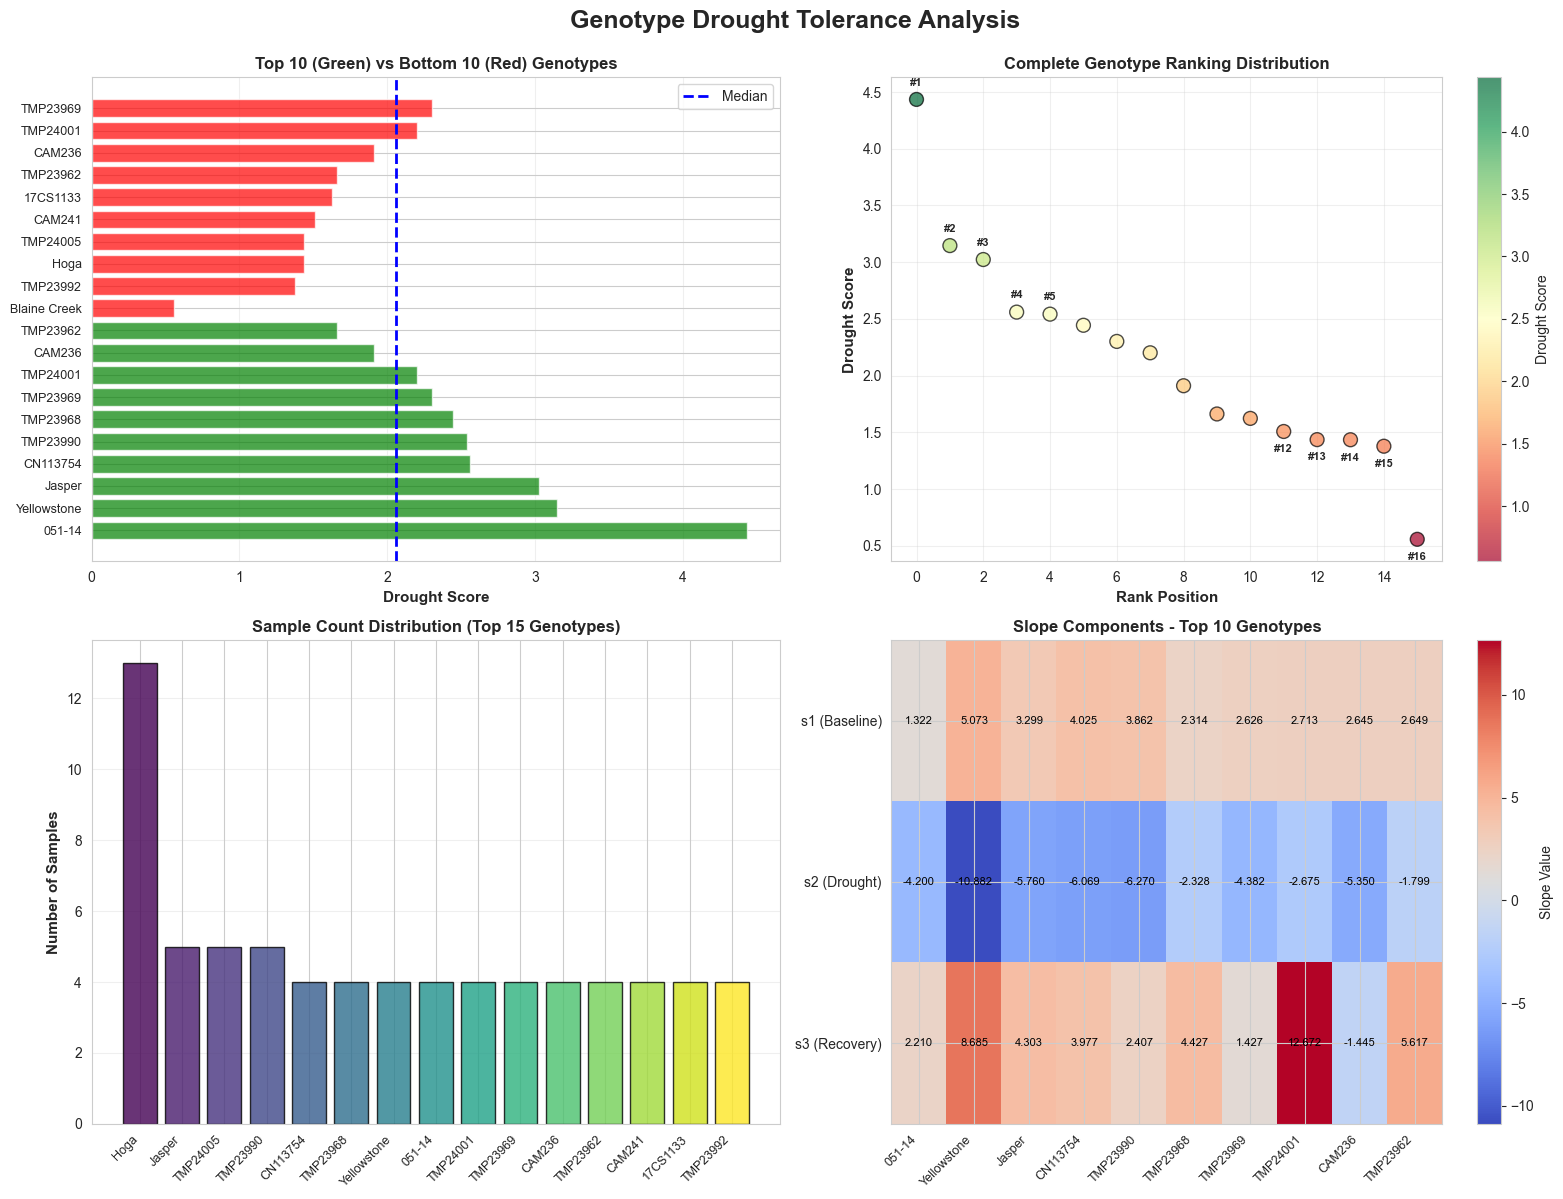

✓ Visualization complete


In [29]:
# ============================================================================
# VISUALIZE GENOTYPE DROUGHT TOLERANCE RANKINGS
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Genotype Drought Tolerance Analysis', fontsize=18, fontweight='bold', y=0.995)

# 1. Horizontal Bar Chart - Top 10 and Bottom 10
ax1 = axes[0, 0]
top_10 = genotype_scores.head(10)
bottom_10 = genotype_scores.tail(10).sort_values('drought_score', ascending=True)

combined = pd.concat([top_10, bottom_10])
colors = ['green' if i < 10 else 'red' for i in range(len(combined))]

y_pos = np.arange(len(combined))
ax1.barh(y_pos, combined['drought_score'], color=colors, alpha=0.7)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(combined['Genotype'], fontsize=9)
ax1.set_xlabel('Drought Score', fontsize=11, fontweight='bold')
ax1.set_title('Top 10 (Green) vs Bottom 10 (Red) Genotypes', fontsize=12, fontweight='bold')
ax1.axvline(x=combined['drought_score'].median(), color='blue', linestyle='--', linewidth=2, label='Median')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# 2. Full Ranking Scatter Plot with Rank Numbers
ax2 = axes[0, 1]
x_pos = np.arange(len(genotype_scores))
scatter = ax2.scatter(x_pos, genotype_scores['drought_score'], 
                     c=genotype_scores['drought_score'], 
                     cmap='RdYlGn', s=100, alpha=0.7, edgecolors='black', linewidth=1)
ax2.set_xlabel('Rank Position', fontsize=11, fontweight='bold')
ax2.set_ylabel('Drought Score', fontsize=11, fontweight='bold')
ax2.set_title('Complete Genotype Ranking Distribution', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax2, label='Drought Score')

# Add rank annotations for top 5 and bottom 5
for i in range(min(5, len(genotype_scores))):
    row = genotype_scores.iloc[i]
    ax2.annotate(f"#{int(row['rank'])}", (i, row['drought_score']), 
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, fontweight='bold')

for i in range(max(0, len(genotype_scores)-5), len(genotype_scores)):
    row = genotype_scores.iloc[i]
    ax2.annotate(f"#{int(row['rank'])}", (i, row['drought_score']), 
                textcoords="offset points", xytext=(0,-15), ha='center', fontsize=8, fontweight='bold')

# 3. Sample Count per Genotype
ax3 = axes[1, 0]
genotype_scores_sorted_samples = genotype_scores.sort_values('num_samples', ascending=False).head(15)
colors_samples = plt.cm.viridis(np.linspace(0, 1, len(genotype_scores_sorted_samples)))
ax3.bar(range(len(genotype_scores_sorted_samples)), 
       genotype_scores_sorted_samples['num_samples'], 
       color=colors_samples, alpha=0.8, edgecolor='black')
ax3.set_xticks(range(len(genotype_scores_sorted_samples)))
ax3.set_xticklabels(genotype_scores_sorted_samples['Genotype'], rotation=45, ha='right', fontsize=9)
ax3.set_ylabel('Number of Samples', fontsize=11, fontweight='bold')
ax3.set_title('Sample Count Distribution (Top 15 Genotypes)', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# 4. Score Components Heatmap - Top 10
ax4 = axes[1, 1]
top_10_heatmap = genotype_scores.head(10)[['Genotype', 's1_baseline', 's2_drought_onset', 's3_predicted_recovery']].set_index('Genotype')
im = ax4.imshow(top_10_heatmap.T, cmap='coolwarm', aspect='auto')
ax4.set_xticks(range(len(top_10_heatmap)))
ax4.set_xticklabels(top_10_heatmap.index, rotation=45, ha='right', fontsize=9)
ax4.set_yticks(range(len(top_10_heatmap.columns)))
ax4.set_yticklabels(['s1 (Baseline)', 's2 (Drought)', 's3 (Recovery)'], fontsize=10)
ax4.set_title('Slope Components - Top 10 Genotypes', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax4, label='Slope Value')

# Add value annotations to heatmap
for i in range(len(top_10_heatmap)):
    for j in range(len(top_10_heatmap.columns)):
        text = ax4.text(i, j, f'{top_10_heatmap.iloc[i, j]:.3f}',
                       ha="center", va="center", color="black", fontsize=8)

plt.tight_layout()
plt.show()

print("✓ Visualization complete")

ANALYZING MODEL PERFORMANCE FOR TOP GENOTYPE
Genotype: 051-14
Rank: #1
Drought Score: 4.4351

Number of samples: 4

Model Performance on 051-14:
  R² Score: 0.9483
  RMSE: 0.3362
  MAE: 0.2915
  Mean Prediction: 1.6949
  Mean Actual: 1.6850



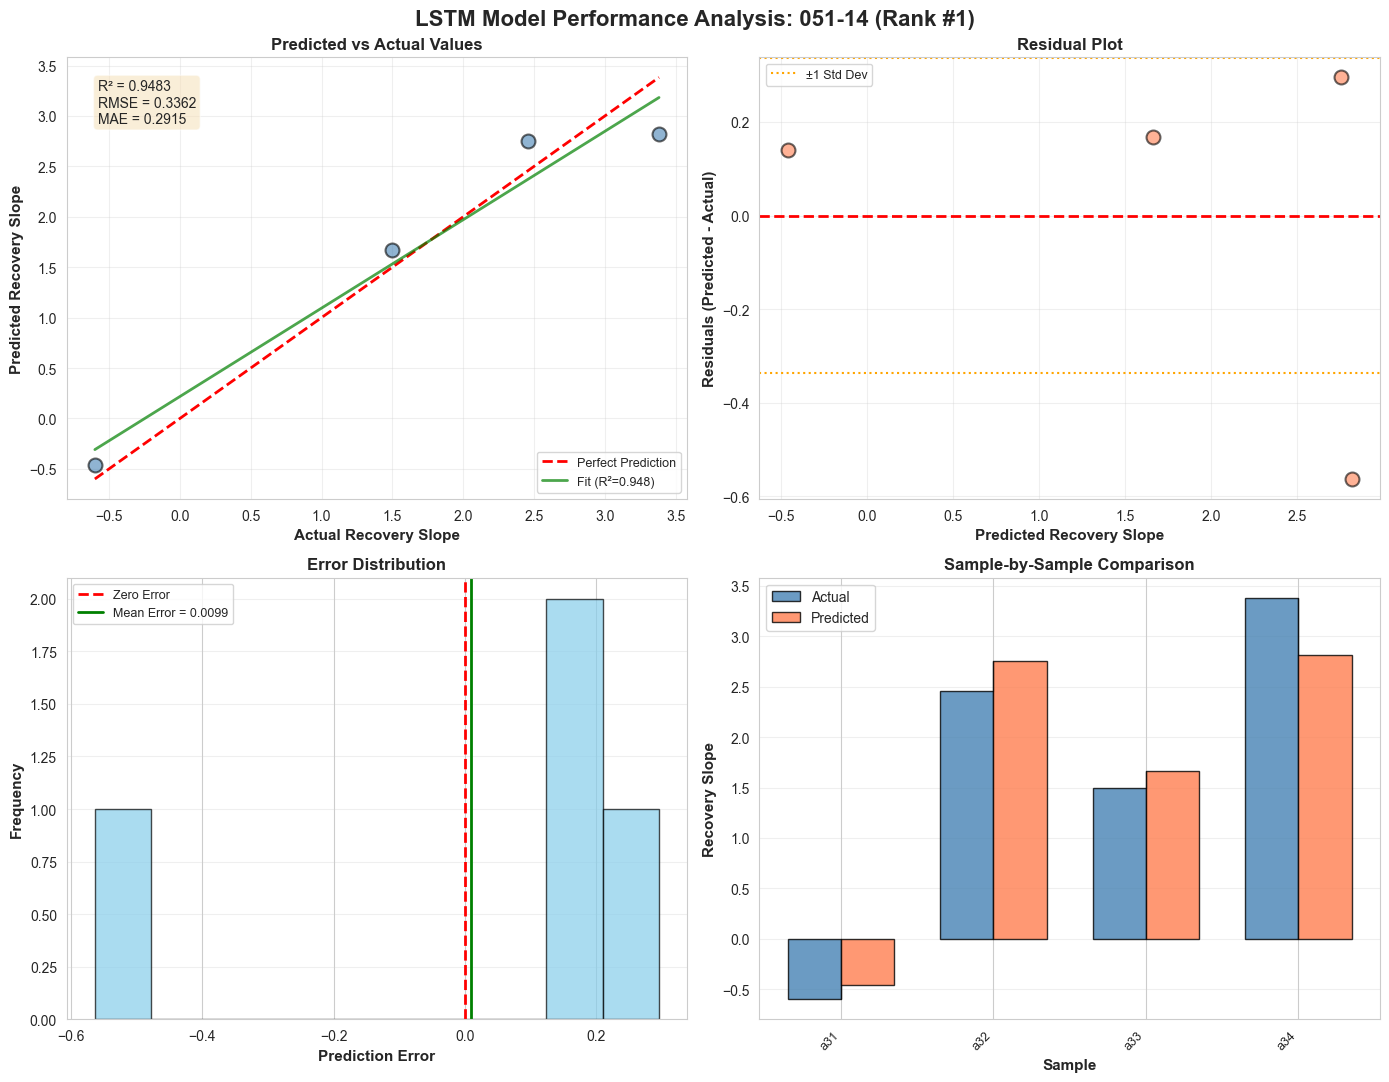

✓ Visualization complete


In [30]:
# ============================================================================
# MODEL PERFORMANCE VISUALIZATION FOR TOP GENOTYPE
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# Select top performing genotype
top_genotype = genotype_scores.iloc[0]['Genotype']
top_genotype_rank = int(genotype_scores.iloc[0]['rank'])
top_genotype_score = genotype_scores.iloc[0]['drought_score']

print("="*70)
print(f"ANALYZING MODEL PERFORMANCE FOR TOP GENOTYPE")
print("="*70)
print(f"Genotype: {top_genotype}")
print(f"Rank: #{top_genotype_rank}")
print(f"Drought Score: {top_genotype_score:.4f}\n")

# Get all samples for this genotype
top_genotype_samples = scores_df[scores_df['Genotype'] == top_genotype]
print(f"Number of samples: {len(top_genotype_samples)}")

# Get predictions and actuals for all samples of this genotype
predictions = []
actuals = []
sample_names = []

for idx, row in top_genotype_samples.iterrows():
    sample_name = row['Sample']
    sample_names.append(sample_name)
    
    # Find this sample in the original data
    sample_idx = next(i for i, s in enumerate(sample_info) if s['Sample'] == sample_name)
    
    # Get prediction (s3)
    pred = row['s3_predicted_recovery']
    predictions.append(pred)
    
    # Get actual target
    actual = y_unified[sample_idx]
    actuals.append(actual)

predictions = np.array(predictions)
actuals = np.array(actuals)

# Calculate metrics
mse = np.mean((predictions - actuals) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(predictions - actuals))
r2 = 1 - (np.sum((actuals - predictions) ** 2) / np.sum((actuals - np.mean(actuals)) ** 2))

print(f"\nModel Performance on {top_genotype}:")
print(f"  R² Score: {r2:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE: {mae:.4f}")
print(f"  Mean Prediction: {predictions.mean():.4f}")
print(f"  Mean Actual: {actuals.mean():.4f}\n")

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle(f'LSTM Model Performance Analysis: {top_genotype} (Rank #{top_genotype_rank})', 
             fontsize=16, fontweight='bold')

# 1. Scatter Plot: Predicted vs Actual
ax1 = axes[0, 0]
ax1.scatter(actuals, predictions, s=100, alpha=0.6, edgecolors='black', linewidth=1.5, c='steelblue')

# Add perfect prediction line
min_val = min(actuals.min(), predictions.min())
max_val = max(actuals.max(), predictions.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

# Add regression line
slope, intercept, r_value, p_value, std_err = linregress(actuals, predictions)
line_x = np.array([min_val, max_val])
line_y = slope * line_x + intercept
ax1.plot(line_x, line_y, 'g-', linewidth=2, alpha=0.7, label=f'Fit (R²={r2:.3f})')

ax1.set_xlabel('Actual Recovery Slope', fontsize=11, fontweight='bold')
ax1.set_ylabel('Predicted Recovery Slope', fontsize=11, fontweight='bold')
ax1.set_title('Predicted vs Actual Values', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Add text box with metrics
textstr = f'R² = {r2:.4f}\nRMSE = {rmse:.4f}\nMAE = {mae:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

# 2. Residual Plot
ax2 = axes[0, 1]
residuals = predictions - actuals
ax2.scatter(predictions, residuals, s=100, alpha=0.6, edgecolors='black', linewidth=1.5, c='coral')
ax2.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax2.set_xlabel('Predicted Recovery Slope', fontsize=11, fontweight='bold')
ax2.set_ylabel('Residuals (Predicted - Actual)', fontsize=11, fontweight='bold')
ax2.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Add standard deviation bands
std_residual = np.std(residuals)
ax2.axhline(y=std_residual, color='orange', linestyle=':', linewidth=1.5, label='±1 Std Dev')
ax2.axhline(y=-std_residual, color='orange', linestyle=':', linewidth=1.5)
ax2.legend(fontsize=9)

# 3. Error Distribution (Histogram)
ax3 = axes[1, 0]
ax3.hist(residuals, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
ax3.axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
ax3.axvline(x=residuals.mean(), color='green', linestyle='-', linewidth=2, label=f'Mean Error = {residuals.mean():.4f}')
ax3.set_xlabel('Prediction Error', fontsize=11, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax3.set_title('Error Distribution', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)

# 4. Sample-by-Sample Comparison
ax4 = axes[1, 1]
x_pos = np.arange(len(sample_names))
width = 0.35

bars1 = ax4.bar(x_pos - width/2, actuals, width, label='Actual', color='steelblue', alpha=0.8, edgecolor='black')
bars2 = ax4.bar(x_pos + width/2, predictions, width, label='Predicted', color='coral', alpha=0.8, edgecolor='black')

ax4.set_xlabel('Sample', fontsize=11, fontweight='bold')
ax4.set_ylabel('Recovery Slope', fontsize=11, fontweight='bold')
ax4.set_title('Sample-by-Sample Comparison', fontsize=12, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels([s.split('_')[0][-3:] for s in sample_names], rotation=45, ha='right', fontsize=9)
ax4.legend(fontsize=10)
ax4.grid(axis='y', alpha=0.3)

# Add error bars
for i, (pred, act) in enumerate(zip(predictions, actuals)):
    ax4.plot([i, i], [act, pred], 'k-', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

print("✓ Visualization complete")